# Tiền xử lý dữ liệu — London Crime Visualization

Notebook này thực hiện  bước 1 (Thu thập & tiền xử lý) trong rubric đồ án

## 1. Nguồn dữ liệu thu thập

**Bài toán:** phân tích phân bố tội phạm được ghi nhận tại 32 borough do Metropolitan Police Service, gọi tắt MPS, phụ trách và đối chiếu với dân số, nguồn lực cảnh sát. Câu hỏi chính: *borough nào có tỷ lệ tội phạm cao, xu hướng theo thời gian ra sao, và số lượng ward officer có liên quan thế nào?*

Dữ liệu lấy từ **London Datastore** của Greater London Authority và **Nomis / ONS** — URL và mã SHA-256 từng tệp nằm trong `data/SOURCE_MANIFEST.csv`.

| Nhóm | Nguồn | Tệp thô | Vai trò |
|---|---|---|---|
| Tội phạm | [MPS Recorded Crime: Geographic Breakdown](https://data.london.gov.uk/dataset/mps-recorded-crime-geographic-breakdown-exy3m) | 6 CSV: borough / ward / LSOA × (lịch sử, 24 tháng gần nhất) | Fact table |
| Dân số | [Census 2021 TS001 — Nomis](https://www.nomisweb.co.uk/sources/census_2021_bulk) | `census2021-ts001-lsoa.csv` | Mẫu số tính tỷ lệ / 1.000 dân; ánh xạ LSOA → borough |
| Nhân lực cảnh sát | [MPS Dedicated Ward Officer Abstractions and Strengths](https://data.london.gov.uk/dataset/mps-dedicated-ward-officer-abstractions-and-strengths-e16kd) | `.xlsx` 2 sheet (`Strengths`, `Sheet1`) | FTE & giờ bị điều động |
| Tiếp cận đồn (lịch sử 2013) | [Police front counter access times](https://data.london.gov.uk/dataset/police-front-counter-access-times-2g1p1) | `lsoatimings.csv`, `police_front_counter_locations_2013.csv` | Bối cảnh lịch sử, **không** trộn vào chuỗi hiện tại |
| Ranh giới | [Statistical GIS Boundary Files for London](https://data.london.gov.uk/dataset/statistical-gis-boundary-files-for-london-20od9) | `LB_LSOA2021_shp.zip` | Bản đồ ở dashboard (không dùng trong notebook này) |

### Từ điển dữ liệu (dữ liệu thô)

| Bảng | Cột | Ý nghĩa |
|---|---|---|
| `crime_*` dạng wide | `Group`, `SubGroup` | Nhóm / nhóm con tội phạm (13 nhóm, ~40 nhóm con) |
| | `BOCU` hoặc `LookUp_BoroughName` hoặc `Borough` | Borough (tên, hoặc mã E09… ở cấp LSOA) |
| | `WardCode`, `WardName` | Mã / tên phường (chỉ cấp ward) |
| | `LSOA Code`, `LSOA Name` | Mã / tên LSOA 2021 (chỉ cấp LSOA) |
| | `YYYYMM` (vd `202408`) | Số vụ ghi nhận trong tháng đó — mỗi tháng một cột |
| `census_ts001` | `geography code`, `geography` | Mã / tên LSOA (tên = *tên borough + mã 4 ký tự*) |
| | `Residence type: Total; measures: Value` | Dân số thường trú 2021 |
| `dwo_strengths` | `Date`, `Department`, `Team`, `Rank`, `FTE` | Cuối tháng, borough, phường, ngạch Constable/PCSO, số FTE |
| `dwo_activity` | `Month of Abstraction`, `Borough`, `Team`, `Abstracted From Duty`, `Abstraction Minutes` | Tháng, borough, phường, cờ Yes/No bị điều động, số phút |
| `travel_2013` | `lsoa`, `pre12`, `pre24`, `post12`, `post24` | Thời gian đi tới quầy tiếp dân gần nhất (phút), trước/sau đóng cửa; `600` là giá trị giữ chỗ |

In [1]:
import hashlib
import json
import re
import urllib.request
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd

# Notebook nằm trong notebooks/ → thư mục gốc là thư mục cha
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RAW = ROOT / 'data' / 'raw'
OUT = ROOT / 'data' / 'processed' / 'notebook_preprocess'
OUT.mkdir(parents=True, exist_ok=True)

MONTH_COL = re.compile(r'20\d{4}')   # cột tháng dạng YYYYMM
quality = {}                          # nhật ký chất lượng, lưu ở cuối bước 4

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 160)

manifest = pd.read_csv(ROOT / 'data' / 'SOURCE_MANIFEST.csv')
manifest[['dataset_id', 'relative_path', 'usage', 'downloaded_on']]

,dataset_id,relative_path,usage,downloaded_on
0,CRIME_LSOA_HIST,data/raw/crime/mps_lsoa_level_crime_historical...,core,2026-09-04
1,CRIME_LSOA_RECENT,data/raw/crime/mps_lsoa_level_crime_recent_202...,core,2026-09-04
2,CRIME_WARD_HIST,data/raw/crime/mps_ward_level_crime_historical...,core,2026-09-04
3,CRIME_WARD_RECENT,data/raw/crime/mps_ward_level_crime_recent_202...,core,2026-09-04
4,CRIME_BOROUGH_HIST,data/raw/crime/mps_borough_level_crime_histori...,core,2026-09-04
5,CRIME_BOROUGH_RECENT,data/raw/crime/mps_borough_level_crime_recent_...,core,2026-09-04
6,POPULATION_TS001,data/raw/population/census2021-ts001.zip,core,2026-09-05
7,LSOA_BOUNDARY,data/raw/boundaries/LB_LSOA2021_shp.zip,core,2026-09-04
8,DWO_WORKFORCE,data/raw/security/MPS_Dedicated_Ward_Officer_A...,core,2026-09-05
9,FRONT_COUNTER_TRAVEL_2013,data/raw/security/lsoa_police_front_counter_tr...,optional_historical,2026-09-04


## 2. Tiến hành tải dữ liệu về

Với mỗi dòng trong manifest: tải → kiểm tra SHA-256 → giải nén `.zip`. 

In [2]:
def sha256(path):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(1 << 20), b''):
            h.update(chunk)
    return h.hexdigest().upper()


def download(url, dest):
    dest.parent.mkdir(parents=True, exist_ok=True)
    tmp = dest.with_suffix(dest.suffix + '.part')               # tải vào tệp tạm, xong mới đổi tên
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})  # tránh lỗi 403
    with urllib.request.urlopen(req, timeout=180) as r, open(tmp, 'wb') as f:
        while chunk := r.read(1 << 20):
            f.write(chunk)
    tmp.replace(dest)


results = []
for row in manifest.itertuples():
    dest, expected = ROOT / row.relative_path, row.sha256.upper()
    try:
        if dest.exists() and sha256(dest) == expected:
            status = 'đã có, đúng hash'
        else:
            download(row.direct_download, dest)
            if sha256(dest) == expected:
                status = 'đã tải, đúng hash'
            else:
                dest.unlink()                                    # xoá tệp sai để lần chạy sau tải lại
                status = 'SAI HASH (đã xoá)'
    except Exception as e:                                       # báo lỗi, đi tiếp dataset khác
        status = f'LỖI: {e}'
    results.append({'dataset_id': row.dataset_id, 'status': status})

download_log = pd.DataFrame(results)
download_log

,dataset_id,status
0,CRIME_LSOA_HIST,"đã có, đúng hash"
1,CRIME_LSOA_RECENT,"đã có, đúng hash"
2,CRIME_WARD_HIST,"đã có, đúng hash"
3,CRIME_WARD_RECENT,"đã có, đúng hash"
4,CRIME_BOROUGH_HIST,"đã có, đúng hash"
5,CRIME_BOROUGH_RECENT,"đã có, đúng hash"
6,POPULATION_TS001,"đã có, đúng hash"
7,LSOA_BOUNDARY,"đã có, đúng hash"
8,DWO_WORKFORCE,"đã có, đúng hash"
9,FRONT_COUNTER_TRAVEL_2013,"đã có, đúng hash"


### Giải nén `.zip`


In [3]:
def extract_member(zip_path, member_name, out_dir):
    """Giải nén 1 tệp (khớp theo tên cuối) từ zip vào out_dir, bỏ qua nếu đã có."""
    target = out_dir / member_name
    if target.exists():
        return 'đã có'
    with zipfile.ZipFile(zip_path) as zf:
        matches = [m for m in zf.namelist()
                   if m.split('/')[-1] == member_name and not m.startswith('__MACOSX')] # bỏ qua tệp __MACOSX
        if not matches:
            raise FileNotFoundError(f'{member_name} không có trong {zip_path.name}')
        out_dir.mkdir(parents=True, exist_ok=True)
        target.write_bytes(zf.read(matches[0]))
    return 'đã giải nén'


def extract_folder(zip_path, prefix, out_dir):
    """Giải nén toàn bộ thư mục `prefix/` trong zip vào out_dir (dùng cho shapefile)."""
    if (out_dir / prefix).exists():
        return 'đã có'
    with zipfile.ZipFile(zip_path) as zf:
        members = [m for m in zf.namelist() if m.startswith(prefix + '/') and not m.endswith('/')]
        zf.extractall(out_dir, members=members)
    return 'đã giải nén'


R = RAW
print('census   ', extract_member(R / 'population/census2021-ts001.zip', 'census2021-ts001-lsoa.csv',
                                  R / 'population/census2021-ts001'))
print('travel   ', extract_member(R / 'security/lsoa_police_front_counter_travel_times_2013.zip', 'lsoatimings.csv',
                                  R / 'security/lsoa_police_front_counter_travel_times_2013'))
print('boundary ', extract_folder(R / 'boundaries/LB_LSOA2021_shp.zip', 'LB_shp',
                                  R / 'boundaries/LB_LSOA2021_shp'))

census    đã có
travel    đã có
boundary  đã có


In [4]:
# Kiểm tra mọi tệp mà bước tiếp theo (và pipeline chính) cần
needed = [
    'data/raw/crime/mps_borough_level_crime_historical_2010_04_to_2024_07.csv',
    'data/raw/crime/mps_borough_level_crime_recent_2024_08_to_2026_07.csv',
    'data/raw/crime/mps_ward_level_crime_historical_2010_04_to_2024_07.csv',
    'data/raw/crime/mps_ward_level_crime_recent_2024_08_to_2026_07.csv',
    'data/raw/crime/mps_lsoa_level_crime_historical_2019_03_to_2024_07.csv',
    'data/raw/crime/mps_lsoa_level_crime_recent_2024_08_to_2026_07.csv',
    'data/raw/population/census2021-ts001/census2021-ts001-lsoa.csv',
    'data/raw/security/MPS_Dedicated_Ward_Officer_Abstractions_and_Strengths.xlsx',
    'data/raw/security/lsoa_police_front_counter_travel_times_2013/lsoatimings.csv',
    'data/raw/security/police_front_counter_locations_2013.csv',
    'data/raw/boundaries/LB_LSOA2021_shp/LB_shp',
]
missing_files = [p for p in needed if not (ROOT / p).exists()]
for p in needed:
    print('OK   ' if p not in missing_files else 'THIẾU', p)
if missing_files:
    raise FileNotFoundError('Thiếu dữ liệu — xem cột status ở bảng tải phía trên; tải tay từ source_page trong manifest nếu cần.')

OK    data/raw/crime/mps_borough_level_crime_historical_2010_04_to_2024_07.csv
OK    data/raw/crime/mps_borough_level_crime_recent_2024_08_to_2026_07.csv
OK    data/raw/crime/mps_ward_level_crime_historical_2010_04_to_2024_07.csv
OK    data/raw/crime/mps_ward_level_crime_recent_2024_08_to_2026_07.csv
OK    data/raw/crime/mps_lsoa_level_crime_historical_2019_03_to_2024_07.csv
OK    data/raw/crime/mps_lsoa_level_crime_recent_2024_08_to_2026_07.csv
OK    data/raw/population/census2021-ts001/census2021-ts001-lsoa.csv
OK    data/raw/security/MPS_Dedicated_Ward_Officer_Abstractions_and_Strengths.xlsx
OK    data/raw/security/lsoa_police_front_counter_travel_times_2013/lsoatimings.csv
OK    data/raw/security/police_front_counter_locations_2013.csv
OK    data/raw/boundaries/LB_LSOA2021_shp/LB_shp


## 3. Preview data

Đọc toàn bộ bảng thô vào bộ nhớ, thống kê kích thước / thiếu / kỳ dữ liệu

In [5]:
raw = {}
for level in ['borough', 'ward', 'lsoa']:
    for path in sorted((RAW / 'crime').glob(f'mps_{level}_*.csv')):
        part = 'hist' if 'historical' in path.name else 'recent'
        raw[f'crime_{level}_{part}'] = pd.read_csv(path)

raw['census_ts001'] = pd.read_csv(RAW / 'population/census2021-ts001/census2021-ts001-lsoa.csv')
BOOK = RAW / 'security/MPS_Dedicated_Ward_Officer_Abstractions_and_Strengths.xlsx'
raw['dwo_strengths'] = pd.read_excel(BOOK, sheet_name='Strengths')
raw['dwo_activity'] = pd.read_excel(BOOK, sheet_name='Sheet1')
raw['travel_2013'] = pd.read_csv(RAW / 'security/lsoa_police_front_counter_travel_times_2013/lsoatimings.csv')
raw['counters_2013'] = pd.read_csv(RAW / 'security/police_front_counter_locations_2013.csv')


def span(df):
    """"Tính thời gian của tệp dữ liệu"""
    months = [c for c in df if MONTH_COL.fullmatch(c)]
    return f'{months[0]} → {months[-1]} ({len(months)} tháng)' if months else ''


profile = pd.DataFrame([{
    'bảng': name, 'dòng': len(df), 'cột': df.shape[1],
    'ô thiếu': int(df.isna().sum().sum()), 'kỳ dữ liệu': span(df),
} for name, df in raw.items()])
profile

,bảng,dòng,cột,ô thiếu,kỳ dữ liệu
0,crime_borough_hist,1125,51,0,202008 → 202407 (48 tháng)
1,crime_borough_recent,991,27,0,202408 → 202607 (24 tháng)
2,crime_ward_hist,20931,53,0,202008 → 202407 (48 tháng)
3,crime_ward_recent,18806,29,0,202408 → 202607 (24 tháng)
4,crime_lsoa_hist,121222,53,0,202008 → 202407 (48 tháng)
5,crime_lsoa_recent,106304,29,0,202408 → 202607 (24 tháng)
6,census_ts001,35672,6,0,
7,dwo_strengths,73567,7,0,
8,dwo_activity,126230,8,0,
9,travel_2013,4969,6,4969,


In [6]:
total_rows = int(profile['dòng'].sum())
print(f'Số bảng        : {len(raw)}')
print(f'Tổng số dòng thô   : {total_rows:,}')
assert len(raw) >= 3 and total_rows >= 5000, 'Dataset không hợp lệ theo rubric'
quality['raw_profile'] = profile.to_dict('records')

Số bảng        : 11
Tổng số dòng thô   : 509,954


In [7]:
# Xem 5 dòng đầu của từng nhóm bảng (cột tháng chỉ hiện 4 tháng đầu cho gọn)
def peek(df, n=5, months=4):
    ids = [c for c in df if not MONTH_COL.fullmatch(c)]
    mcols = [c for c in df if MONTH_COL.fullmatch(c)][:months]
    return df[ids + mcols].head(n)

print('crime_borough_recent'); display(peek(raw['crime_borough_recent']))
print('crime_ward_hist');      display(peek(raw['crime_ward_hist']))
print('crime_lsoa_recent');    display(peek(raw['crime_lsoa_recent']))

crime_borough_recent


,Group,SubGroup,BOCU,202408,202409,202410,202411
0,MISCELLANEOUS CRIMES AGAINST SOCIETY,MISC CRIMES AGAINST SOCIETY,Aviation Policing,0,0,0,0
1,ARSON AND CRIMINAL DAMAGE,ARSON,Barking and Dagenham,10,9,5,7
2,ARSON AND CRIMINAL DAMAGE,CRIMINAL DAMAGE,Barking and Dagenham,114,80,103,96
3,BURGLARY,BURGLARY BUSINESS AND COMMUNITY,Barking and Dagenham,26,32,29,25
4,BURGLARY,RES BURGLARY OF A HOME,Barking and Dagenham,35,31,48,40


crime_ward_hist


,Group,SubGroup,WardName,WardCode,LookUp_BoroughName,202008,202009,202010,202011
0,ARSON AND CRIMINAL DAMAGE,ARSON,Heathrow Villages,E05013570,Aviation Security (SO18) (Legacy Only),0,0,0,0
1,ARSON AND CRIMINAL DAMAGE,CRIMINAL DAMAGE,Heathrow Villages,E05013570,Aviation Security (SO18) (Legacy Only),0,0,0,0
2,BURGLARY,RES BURGLARY OF A HOME,Heathrow Villages,E05013570,Aviation Security (SO18) (Legacy Only),0,0,0,0
3,BURGLARY,BURGLARY BUSINESS AND COMMUNITY,Heathrow Villages,E05013570,Aviation Security (SO18) (Legacy Only),0,0,0,0
4,BURGLARY,RES BURGLARY OF UNCONNECTED BUILDING,Heathrow Villages,E05013570,Aviation Security (SO18) (Legacy Only),0,0,0,0


crime_lsoa_recent


,LSOA Code,LSOA Name,Borough,Group,SubGroup,202408,202409,202410,202411
0,E01000005,City of London 001E,E09000001,PUBLIC ORDER OFFENCES,"PUBLIC FEAR, ALARM OR DISTRESS",0,0,0,0
1,E01000005,City of London 001E,E09000001,THEFT,BICYCLE THEFT,0,0,0,0
2,E01000005,City of London 001E,E09000001,THEFT,OTHER THEFT,0,0,0,0
3,E01000005,City of London 001E,E09000001,THEFT,THEFT FROM THE PERSON,0,1,0,0
4,E01000005,City of London 001E,E09000001,VIOLENCE AGAINST THE PERSON,VIOLENCE WITH INJURY,0,0,0,0


In [8]:
for name in ['census_ts001', 'dwo_strengths', 'dwo_activity', 'travel_2013', 'counters_2013']:
    print(name); display(raw[name].head(4))

census_ts001


,date,geography,geography code,Residence type: Total; measures: Value,Residence type: Lives in a household; measures: Value,Residence type: Lives in a communal establishment; measures: Value
0,2021,Hartlepool 001A,E01011954,2284,2284,0
1,2021,Hartlepool 001B,E01011969,1344,1344,0
2,2021,Hartlepool 001C,E01011970,1070,1070,0
3,2021,Hartlepool 001D,E01011971,1323,1323,0


dwo_strengths


,Date,Buisness Group,OCU,Department,Team,Rank,FTE
0,2021-08-31,Frontline Policing,BCU Central East,Hackney Borough,Brownswood Hall Ward,Constable,2.0
1,2021-08-31,Frontline Policing,BCU Central East,Hackney Borough,Cazenove Ward,Constable,2.0
2,2021-08-31,Frontline Policing,BCU Central East,Hackney Borough,Cazenove Ward,PCSO,1.0
3,2021-08-31,Frontline Policing,BCU Central East,Hackney Borough,Clissold Ward,Constable,2.0


dwo_activity


,Month of Abstraction,BCU,Borough,Team,Abstracted From Duty,Abstracted Type,Abstraction Minutes,Ward_Code
0,2021-08-01,BCU Central East,Tower Hamlets Borough,Bromley South Ward,No,Not Abstracted,37023.0,E05009322
1,2021-12-01,BCU North West,Brent Borough,Barnhill Ward,No,Not Abstracted,23070.0,E05000086
2,2022-02-01,BCU East,Redbridge Borough,Goodmayes Ward,No,Not Abstracted,30837.0,E05011244
3,2022-03-01,BCU South East,Greenwich Borough,Woolwich Common Ward,No,Not Abstracted,35370.0,E05000229


travel_2013


,lsoa,pre12,pre24,post12,post24,Unnamed: 5
0,E01002839,10.740509,10.740509,10.740509,28.259291,NaN
1,E01002838,12.672469,12.672469,23.342200,45.000000,NaN
2,E01002837,14.833706,14.833706,20.100021,37.518671,NaN
3,E01002835,16.089742,16.089742,16.967888,32.536409,NaN


counters_2013


,name,local authority,longitude,latitude,status,current,proposed
0,BARKING LEARNING ANNEX,BARKING & DAGENHAM,0.080059,51.537449,keep,24HR,24HR
1,MARKS GATE POLICE OFFICE,BARKING & DAGENHAM,0.137554,51.583589,cut,DAY TIME,CLOSED
2,DAGENHAM POLICE STATION,BARKING & DAGENHAM,0.165430,51.545033,cut,24HR,CLOSED
3,BARKING POLICE STATION,BARKING & DAGENHAM,0.080090,51.538344,cut,24HR,CLOSED


## 4. Thực hiện làm sạch dữ liệu

Luồng xử lý (mỗi bước có ghi chú trong code):

| Bước | Nội dung |
|---|---|
| 4.1 | Chuẩn hoá tên cột, khoá chuỗi |
| 4.2 | Kiểm tra giá trị: thiếu, không phải số, âm, không nguyên, trùng khoá |
| 4.3 | Wide → long, chuẩn hoá ngày `YYYYMM` → `datetime` |
| 4.4 | Nối bản lịch sử + bản gần đây |
| 4.5 | Dân số Census 2021 + phạm vi 32 borough MPS |
| 4.6 | **Join** crime ⨝ dân số, tính tỷ lệ / 1.000 dân |
| 4.7 | Outlier theo IQR: gắn cờ, giữ lại |
| 4.8 | **Calculated fields**: rolling 12 tháng, MoM, YoY, hotspot |
| 4.9 | Nhân lực cảnh sát: làm sạch + **Join** vào bảng tháng |
| 4.10 | Thời gian tới đồn 2013 (giá trị giữ chỗ 600) |
| 4.11 | Kiểm tra bảo toàn, đối chiếu pipeline chính, lưu kết quả |

### 4.1 Chuẩn hoá tên cột & khoá

- Đổi tên cột về `snake_case` thống nhất giữa 3 cấp borough / ward / LSOA.
- Cắt khoảng trắng thừa và gộp nhiều khoảng trắng thành một ở **mọi cột khoá** (chuỗi).
- Khoá bị thiếu → dừng, không đoán.

In [9]:
RENAME = {
    'Group': 'crime_group', 'SubGroup': 'crime_subgroup',
    'BOCU': 'borough_name', 'LookUp_BoroughName': 'borough_name',
    'LSOA Code': 'lsoa_code', 'LSOA Name': 'lsoa_name', 'Borough': 'borough_code',
    'WardCode': 'ward_code', 'WardName': 'ward_name',
}


def standardise(df):
    df = df.rename(columns=RENAME)
    ids = [c for c in df if not MONTH_COL.fullmatch(c)]          # cột khoá = mọi cột không phải YYYYMM
    for c in ids:
        df[c] = df[c].astype('string').str.strip().str.replace(r'\s+', ' ', regex=True)
    if df[ids].isna().any().any():
        raise ValueError('Thiếu giá trị ở cột khoá')
    return df, ids


crime = {k: standardise(v) for k, v in raw.items() if k.startswith('crime_')}
for k, (df, ids) in crime.items():
    print(f'{k:<22} khoá: {ids}')

crime_borough_hist     khoá: ['crime_group', 'crime_subgroup', 'borough_name']
crime_borough_recent   khoá: ['crime_group', 'crime_subgroup', 'borough_name']
crime_ward_hist        khoá: ['crime_group', 'crime_subgroup', 'ward_name', 'ward_code', 'borough_name']
crime_ward_recent      khoá: ['crime_group', 'crime_subgroup', 'ward_name', 'ward_code', 'borough_name']
crime_lsoa_hist        khoá: ['lsoa_code', 'lsoa_name', 'borough_code', 'crime_group', 'crime_subgroup']
crime_lsoa_recent      khoá: ['lsoa_code', 'lsoa_name', 'borough_code', 'crime_group', 'crime_subgroup']


### 4.2 Kiểm tra giá trị số vụ

Mỗi ô tháng phải là **số nguyên không âm, không thiếu**; mỗi tổ hợp khoá chỉ xuất hiện **một lần**. Vi phạm → `ValueError`.

In [10]:
def validate_wide(df, ids, name):
    """Kiểm tra + ép kiểu cột tháng (tại chỗ). Trả về (danh sách cột tháng, báo cáo)."""
    months = [c for c in df if MONTH_COL.fullmatch(c)]
    values = df[months].apply(pd.to_numeric, errors='coerce') # chuyển sang số nếu k được thì sẽ thành NaN
    report = {
        'bảng': name, 'dòng': len(df), 'tháng': len(months),
        'thiếu/không phải số': int(values.isna().sum().sum()),
        'âm': int((values < 0).sum().sum()),
        'không nguyên': int((values.notna() & (values % 1 != 0)).sum().sum()),
        'trùng khoá': int(df.duplicated(ids).sum()),
    }
    if any(v for k, v in report.items() if k not in ('bảng', 'dòng', 'tháng')):
        raise ValueError(f'Dữ liệu không hợp lệ: {report}')
    df[months] = values.astype('int32')
    return months, report


checks, months_of = [], {}
for k, (df, ids) in crime.items():
    months_of[k], rep = validate_wide(df, ids, k)
    checks.append(rep)

quality['validation'] = checks
pd.DataFrame(checks)

,bảng,dòng,tháng,thiếu/không phải số,âm,không nguyên,trùng khoá
0,crime_borough_hist,1125,48,0,0,0,0
1,crime_borough_recent,991,24,0,0,0,0
2,crime_ward_hist,20931,48,0,0,0,0
3,crime_ward_recent,18806,24,0,0,0,0
4,crime_lsoa_hist,121222,48,0,0,0,0
5,crime_lsoa_recent,106304,24,0,0,0,0


### 4.3 Wide → long

Mỗi cột `YYYYMM` trở thành một dòng (`month`, `crime_count`). Ngày chuẩn hoá `YYYYMM` → `datetime64` (ngày 1 của tháng). Sau khi chuyển, **tổng số vụ phải bằng tổng ở bảng wide**.

Cấp **LSOA** có ~8 triệu dòng sau khi chuyển; để nhẹ bộ nhớ, ta cộng các loại tội phạm theo từng LSOA *trước* khi chuyển (xem 4.5) — đủ cho phân tích tỷ lệ theo LSOA.

In [11]:
def to_long(df, ids, months):
    long = df.melt(id_vars=ids, value_vars=months, var_name='month', value_name='crime_count')
    long['month'] = pd.to_datetime(long['month'], format='%Y%m')
    assert int(long.crime_count.sum()) == int(df[months].to_numpy().sum()), 'Tổng không bảo toàn'
    return long


long = {}
for k in crime:
    if 'lsoa' in k:
        continue                       # xử lý riêng ở 4.5
    df, ids = crime[k]
    long[k] = to_long(df, ids, months_of[k])
    print(f'{k:<22} {len(long[k]):>10,} dòng | {int(long[k].crime_count.sum()):>12,} vụ')

crime_borough_hist         54,000 dòng |    3,470,320 vụ
crime_borough_recent       23,784 dòng |    1,844,927 vụ
crime_ward_hist         1,004,688 dòng |    3,341,599 vụ
crime_ward_recent         451,344 dòng |    1,742,999 vụ


### 4.4 Nối bản lịch sử + bản gần đây

Hai tệp phải không trùng khoá và ghép lại thành chuỗi tháng liên tục.

> Lưu ý: Đối với hai nhóm con `DOMESTIC BURGLARY` (có số liệu đến 07/2023) và `PUBLIC FEAR ALARM OR DISTRESS` (đến 02/2024, sau đó xuất hiện dạng có dấu phẩy) chỉ có trong bản lịch sử. Ta giữ nguyên các nhãn này; tổng theo `crime_group` vẫn nhất quán.

In [12]:
KEYS = {
    'borough': ['borough_name', 'crime_group', 'crime_subgroup', 'month'],
    'ward': ['ward_code', 'ward_name', 'borough_name', 'crime_group', 'crime_subgroup', 'month'],
}
facts = {}
for level in ['borough', 'ward']:
    df = pd.concat([long[f'crime_{level}_hist'], long[f'crime_{level}_recent']], ignore_index=True)
    if df.duplicated(KEYS[level]).any():
        raise ValueError(f'Hai đoạn {level} chồng lấn')
    months = pd.Series(sorted(df.month.unique()))
    assert len(months) == len(pd.date_range(months.min(), months.max(), freq='MS')), 'Tháng không liên tục'
    facts[level] = df
    print(f'{level:<8} {months.min():%Y-%m} → {months.max():%Y-%m} ({len(months)} tháng) | {int(df.crime_count.sum()):,} vụ')

borough  2020-08 → 2026-07 (72 tháng) | 5,315,247 vụ


ward     2020-08 → 2026-07 (72 tháng) | 5,084,598 vụ


### 4.5 Dân số Census 2021 + phạm vi 32 borough MPS

- Tên borough lấy từ cột `geography` của Census bằng cách bỏ mã 4 ký tự cuối (`"Camden 001A"` → `"Camden"`).
- **London** = các LSOA có tên borough trùng 32 borough MPS trong dữ liệu tội phạm **+ City of London**.
- **City of London** có lực lượng cảnh sát riêng là City of London Police → loại khỏi phân tích chính. Các đơn vị phi địa bàn (`Aviation Policing`, sân bay Heathrow/City, `Unknown`) cũng loại. Phần loại ra được **lưu riêng**, không xoá.
- **Join kiểm tra:** mọi mã LSOA trong dữ liệu tội phạm phải có trong Census.

In [13]:
census = raw['census_ts001'].rename(columns={
    'geography code': 'lsoa_code',
    'Residence type: Total; measures: Value': 'population_2021',
})[['lsoa_code', 'geography', 'population_2021']]
census['borough_name'] = census.geography.str.replace(r'\s\w{4}$', '', regex=True)   # bỏ mã LSOA 4 ký tự

crime_boroughs = set(facts['borough'].borough_name)
london_names = (crime_boroughs | {'City of London'}) & set(census.borough_name)
census_ldn = census[census.borough_name.isin(london_names)].copy()                    # chỉ LSOA của London

if census_ldn.population_2021.isna().any() or (census_ldn.population_2021 <= 0).any():
    raise ValueError('Dân số thiếu hoặc không dương')

dim_borough = (census_ldn[census_ldn.borough_name != 'City of London']
               .groupby('borough_name', as_index=False).population_2021.sum())
assert len(dim_borough) == 32, len(dim_borough)
quality['join_checks'] = {'census_london_lsoa': len(census_ldn), 'mps_boroughs': len(dim_borough)}
print(f'LSOA London trong Census : {len(census_ldn):,}')
print(f'Borough MPS              : {len(dim_borough)} | dân số {int(dim_borough.population_2021.sum()):,}')
dim_borough.sort_values('population_2021', ascending=False).head(5)

LSOA London trong Census : 4,994
Borough MPS              : 32 | dân số 8,791,193


,borough_name,population_2021
6,Croydon,390708
1,Barnet,389348
7,Ealing,367125
23,Newham,351034
3,Brent,339808


In [14]:
# Loại phần ngoài 32 borough (lưu riêng, không xoá) — cấp borough và ward
excluded = {}
for level in ['borough', 'ward']:
    df = facts[level]
    out = ~df.borough_name.isin(dim_borough.borough_name)
    excluded[level] = df[out].copy()
    facts[level] = df[~out].copy()
    print(f'{level:<8} loại {int(out.sum()):>7,} dòng / {int(excluded[level].crime_count.sum()):>8,} vụ:',
          sorted(excluded[level].borough_name.unique()))

borough  loại   3,000 dòng /  100,453 vụ: ['Aviation Policing', 'London Heathrow and London City Airports', 'Unknown']


ward     loại   1,344 dòng /    4,633 vụ: ['Aviation Security (SO18) (Legacy Only)']


In [15]:
# Cấp LSOA: cộng các loại tội phạm theo từng LSOA, mỗi đoạn một bảng rộng (cột tháng), rồi nối theo cột
lsoa_wide = []
for part in ['hist', 'recent']:
    df, ids = crime[f'crime_lsoa_{part}']
    lsoa_wide.append(df.groupby('lsoa_code')[months_of[f'crime_lsoa_{part}']].sum())
lsoa_wide = pd.concat(lsoa_wide, axis=1, join='outer')

# LSOA chỉ xuất hiện ở một đoạn sẽ có ô NaN.
na_cells = int(lsoa_wide.isna().sum().sum())
quality['lsoa_cells_absent_in_one_snapshot'] = na_cells
print('Ô LSOA × tháng vắng mặt ở một đoạn:', na_cells)

# Join kiểm tra: mọi LSOA trong dữ liệu tội phạm phải có trong Census
not_in_census = set(lsoa_wide.index) - set(census_ldn.lsoa_code)
if not_in_census:
    raise ValueError(f'{len(not_in_census)} LSOA tội phạm không có trong Census')
quality['join_checks']['crime_lsoa_codes'] = len(lsoa_wide)
print(f'LSOA có số liệu tội phạm: {len(lsoa_wide):,} / {len(census_ldn):,} LSOA trong Census')

Ô LSOA × tháng vắng mặt ở một đoạn: 0
LSOA có số liệu tội phạm: 4,991 / 4,994 LSOA trong Census


In [16]:
# Nếu có ô vắng mặt, coi là "không có bản ghi" = 0 và ghi rõ vào nhật ký (chỉ khi có)
if na_cells:
    lsoa_wide = lsoa_wide.fillna(0)
lsoa_wide = lsoa_wide.astype('int32')

lsoa_month = (lsoa_wide.reset_index()
              .melt(id_vars='lsoa_code', var_name='month', value_name='crime_count'))
lsoa_month['month'] = pd.to_datetime(lsoa_month.month, format='%Y%m')
lsoa_month = lsoa_month.merge(census_ldn[['lsoa_code', 'borough_name', 'population_2021']],
                              on='lsoa_code', how='left', validate='many_to_one')
excluded['lsoa'] = lsoa_month[lsoa_month.borough_name == 'City of London'].copy()
lsoa_month = lsoa_month[lsoa_month.borough_name != 'City of London'].copy()
lsoa_month['rate_per_1000'] = lsoa_month.crime_count / lsoa_month.population_2021 * 1000
print(f'lsoa_month: {len(lsoa_month):,} dòng | {lsoa_month.lsoa_code.nunique():,} LSOA | '
      f'{int(lsoa_month.crime_count.sum()):,} vụ')

lsoa_month: 359,136 dòng | 4,988 LSOA | 5,055,169 vụ


### 4.6 Join: tội phạm ⨝ dân số, tỷ lệ / 1.000 dân

`validate='many_to_one'` bảo đảm mỗi dòng crime khớp **đúng một** borough. Sau Join, **tổng số vụ không được đổi**.

In [17]:
before = int(facts['borough'].crime_count.sum())
facts_borough = facts['borough'].merge(dim_borough, on='borough_name', how='left', validate='many_to_one')
assert int(facts_borough.crime_count.sum()) == before, 'Join làm đổi tổng số vụ'
assert facts_borough.population_2021.notna().all(), 'Có borough không khớp dân số'

def ratio(num, den, scale=1):
    """num / den × scale; mẫu số ≤ 0 trả NaN thay vì chia cho 0."""
    return num.div(den.where(den > 0)).mul(scale)

facts_borough['rate_per_1000'] = ratio(facts_borough.crime_count, facts_borough.population_2021, 1000)
quality['join_checks']['crime_total_preserved'] = before
quality['join_checks']['excluded_crime_total'] = int(excluded['borough'].crime_count.sum())
print(f'Tổng số vụ (32 borough) được bảo toàn: {before:,}')
facts_borough.head()

Tổng số vụ (32 borough) được bảo toàn: 5,214,794


,crime_group,crime_subgroup,borough_name,month,crime_count,population_2021,rate_per_1000
0,ARSON AND CRIMINAL DAMAGE,ARSON,Barking and Dagenham,2020-08-01,6,218865,0.027414
1,ARSON AND CRIMINAL DAMAGE,CRIMINAL DAMAGE,Barking and Dagenham,2020-08-01,113,218865,0.516300
2,BURGLARY,BURGLARY BUSINESS AND COMMUNITY,Barking and Dagenham,2020-08-01,23,218865,0.105088
3,BURGLARY,DOMESTIC BURGLARY,Barking and Dagenham,2020-08-01,62,218865,0.283280
4,BURGLARY,RES BURGLARY OF A HOME,Barking and Dagenham,2020-08-01,0,218865,0.000000


### 4.7 Outlier theo IQR

Với tổng số vụ **mỗi borough mỗi tháng**, một điểm là outlier nếu nằm ngoài `[Q1 − 1.5·IQR, Q3 + 1.5·IQR]` của riêng borough đó. Đây là **số đếm có thật** nên ta chỉ **gắn cờ** `outlier_iqr`, không xoá, không cắt giá trị.

In [18]:
monthly = (facts_borough.groupby(['borough_name', 'month'], as_index=False).crime_count.sum()
           .merge(dim_borough, on='borough_name', validate='many_to_one')
           .sort_values(['borough_name', 'month'], ignore_index=True))

g = monthly.groupby('borough_name').crime_count
q1, q3 = g.transform(lambda s: s.quantile(.25)), g.transform(lambda s: s.quantile(.75))
iqr = q3 - q1
monthly['outlier_iqr'] = (monthly.crime_count < q1 - 1.5 * iqr) | (monthly.crime_count > q3 + 1.5 * iqr)
quality['outlier_months_retained'] = int(monthly.outlier_iqr.sum())

print(f'Tháng-borough bị gắn cờ outlier: {quality["outlier_months_retained"]} / {len(monthly)} (giữ lại)')
monthly[monthly.outlier_iqr].groupby('borough_name').size().sort_values(ascending=False).head(8).to_frame('số tháng')

Tháng-borough bị gắn cờ outlier: 54 / 2304 (giữ lại)


,số tháng
borough_name,
Kensington and Chelsea,7
Greenwich,4
Haringey,4
Lambeth,4
Westminster,3
Hammersmith and Fulham,3
Islington,3
Wandsworth,2


### 4.8 Calculated fields

| Trường | Công thức | Ý nghĩa |
|---|---|---|
| `year`, `month_number`, `quarter` | từ `month` | Trục thời gian cho lọc / mùa vụ |
| `data_regime` | `legacy` nếu `month < 2024-03`, ngược lại `connect` | Phân biệt hai giai đoạn ghi nhận |
| `rate_per_1000` | `crime_count / population_2021 × 1000` | So sánh công bằng giữa borough đông / thưa dân |
| `rolling_12_count`, `rolling_12_rate` | tổng 12 tháng liên tiếp (và theo dân số) | Làm mượt mùa vụ |
| `mom_pct` | `(x_t − x_{t−1}) / x_{t−1} × 100` | Thay đổi so với tháng trước |
| `yoy_pct` | `(x_t − x_{t−12}) / x_{t−12} × 100` | Thay đổi so với cùng kỳ năm trước |
| `is_hotspot` | tỷ lệ ≥ phân vị 75 của cùng tháng giữa các borough | Cờ hotspot tương đối |

In [19]:
def temporal_fields(frame):
    out = frame.copy()
    out['year'] = out.month.dt.year
    out['month_number'] = out.month.dt.month
    out['quarter'] = out.month.dt.to_period('Q').astype(str)
    out['data_regime'] = np.where(out.month < pd.Timestamp('2024-03-01'), 'legacy', 'connect')
    return out


monthly = temporal_fields(monthly)
monthly['rate_per_1000'] = ratio(monthly.crime_count, monthly.population_2021, 1000)

g = monthly.groupby('borough_name').crime_count            # monthly đã sắp theo (borough, month) nên rolling/shift đúng thứ tự
monthly['rolling_12_count'] = g.transform(lambda s: s.rolling(12, min_periods=12).sum())
monthly['rolling_12_rate'] = ratio(monthly.rolling_12_count, monthly.population_2021, 1000)
monthly['mom_pct'] = ratio(monthly.crime_count - g.shift(1), g.shift(1), 100)
monthly['yoy_pct'] = ratio(monthly.crime_count - g.shift(12), g.shift(12), 100)
monthly['is_hotspot'] = monthly.rate_per_1000 >= monthly.groupby('month').rate_per_1000.transform(lambda s: s.quantile(.75))

assert int(monthly.crime_count.sum()) == before
monthly.tail(3)

,borough_name,month,crime_count,population_2021,outlier_iqr,year,month_number,quarter,data_regime,rate_per_1000,rolling_12_count,rolling_12_rate,mom_pct,yoy_pct,is_hotspot
2301,Westminster,2026-05-01,5546,204242,False,2026,5,2026Q2,connect,27.154062,77669.0,380.279277,-2.221439,-18.501102,True
2302,Westminster,2026-06-01,5753,204242,False,2026,6,2026Q2,connect,28.167566,76530.0,374.702559,3.732420,-16.526407,True
2303,Westminster,2026-07-01,6197,204242,False,2026,7,2026Q3,connect,30.341458,75576.0,370.031629,7.717712,-13.340791,True


### 4.9 Nhân lực cảnh sát: làm sạch + Join

Hai sheet của tệp `.xlsx`:

- **Strengths** — FTE theo borough / phường / ngạch (`Date` là ngày cuối tháng).
- **Sheet1** — số phút ward officer bị điều động khỏi nhiệm vụ phường (`Abstracted From Duty` = Yes/No).

Làm sạch: chuẩn hoá tên borough (bỏ hậu tố ` Borough`, đổi `&` → `and`…), ép `Date` → đầu tháng, ép số, **từ chối** dòng thiếu / âm / borough lạ (lưu `reports/rejected_*.csv` nếu có). Không khử trùng FTE vì bảng gốc có thể lặp bản ghi tổng hợp có chủ đích.

In [20]:
BOROUGH_ALIASES = {
    'Barking & Dagenham': 'Barking and Dagenham', 'Hammersmith & Fulham': 'Hammersmith and Fulham',
    'Kensington & Chelsea': 'Kensington and Chelsea', 'Kingston': 'Kingston upon Thames',
    'Richmond': 'Richmond upon Thames',
}

def borough_names(values):
    return values.astype('string').str.strip().str.replace(r' Borough$', '', regex=True).replace(BOROUGH_ALIASES)

def month_start(values):
    return pd.to_datetime(values, errors='coerce').dt.to_period('M').dt.to_timestamp()


strengths = raw['dwo_strengths'].copy()
activity = raw['dwo_activity'].copy()

strengths['borough_name'] = borough_names(strengths.Department)
strengths['month'] = month_start(strengths.Date)
strengths['FTE'] = pd.to_numeric(strengths.FTE, errors='coerce')

activity['borough_name'] = borough_names(activity.Borough)
activity['month'] = month_start(activity['Month of Abstraction'])
activity['minutes'] = pd.to_numeric(activity['Abstraction Minutes'], errors='coerce')

# Từ chối (không sửa) dòng không hợp lệ
sec_checks = {}
for name, table, measure in [('strengths', strengths, 'FTE'), ('activity', activity, 'minutes')]:
    invalid = table[['borough_name', 'month', measure]].isna().any(axis=1) | (table[measure] < 0)
    invalid |= ~table.borough_name.isin(dim_borough.borough_name)
    sec_checks[f'invalid_{name}'] = int(invalid.sum())
    if invalid.any():
        raise ValueError(f'{name}: {int(invalid.sum())} dòng không hợp lệ — kiểm tra thủ công')
sec_checks['exact_duplicate_strength_rows'] = int(strengths.duplicated().sum())   # chỉ báo cáo
statuses = activity['Abstracted From Duty'].astype(str).str.strip().str.lower()
if not statuses.isin(['yes', 'no']).all():
    raise ValueError('Cờ abstraction ngoài Yes/No')
quality['security'] = {'strength_rows': len(strengths), 'activity_rows': len(activity), **sec_checks}
print(quality['security'])

{'strength_rows': 73567, 'activity_rows': 126230, 'invalid_strengths': 0, 'invalid_activity': 0, 'exact_duplicate_strength_rows': 0}


In [21]:
# Gộp theo (borough, tháng) rồi Join 2 bảng; dùng outer để không mất tháng nào
fte = strengths.groupby(['borough_name', 'month'], as_index=False).FTE.sum().rename(columns={'FTE': 'officer_fte'})
activity['abstracted_minutes'] = activity.minutes.where(statuses.eq('yes'), 0)
act = activity.groupby(['borough_name', 'month'], as_index=False)[['minutes', 'abstracted_minutes']].sum()

security = fte.merge(act, on=['borough_name', 'month'], how='outer', validate='one_to_one')
security = security.merge(dim_borough, on='borough_name', validate='many_to_one')
security['officers_per_10000'] = ratio(security.officer_fte, security.population_2021, 10000)
security['abstraction_hours'] = security.abstracted_minutes / 60
security['abstraction_share_pct'] = ratio(security.abstracted_minutes, security.minutes, 100)
security['abstraction_hours_per_fte'] = ratio(security.abstraction_hours, security.officer_fte)

# Join vào bảng tháng (trái: giữ mọi tháng tội phạm), 1-1 theo (borough, tháng)
monthly_master = monthly.merge(security.drop(columns='population_2021'),
                               on=['borough_name', 'month'], how='left', validate='one_to_one', indicator=True)
assert int(monthly_master.crime_count.sum()) == before

eligible = monthly_master.month >= security.month.min()           # khoảng thời gian chung của hai nguồn
matched = (monthly_master.loc[eligible, '_merge'] == 'both')
if not matched.all():
    raise ValueError('Có tháng trong khoảng chung không khớp nhân lực')
missing_fte = monthly_master.loc[eligible & monthly_master.officer_fte.isna(), ['borough_name', 'month']]
quality['join_checks'].update({
    'security_eligible_months': int(eligible.sum()), 'security_matched_months': int(matched.sum()),
    'fte_observed_months': int(monthly_master.loc[eligible, 'officer_fte'].notna().sum()),
    'fte_missing_months': len(missing_fte),
})
monthly_master = monthly_master.drop(columns='_merge')
print(f'Tháng-borough có nhân lực: {matched.sum():,} / {int(eligible.sum()):,} | thiếu FTE: {len(missing_fte)}')
print('FTE thiếu — KHÔNG điền 0, để NaN. Borough:', missing_fte.borough_name.unique().tolist(),
      '| từ', f'{missing_fte.month.min():%Y-%m}', 'đến', f'{missing_fte.month.max():%Y-%m}')

Tháng-borough có nhân lực: 1,920 / 1,920 | thiếu FTE: 24
FTE thiếu — KHÔNG điền 0, để NaN. Borough: ['Camden'] | từ 2024-08 đến 2026-07


### 4.10 Thời gian tới đồn (2013) — giá trị giữ chỗ `600`

Trong `lsoatimings.csv`, `600` (phút) là giá trị giữ chỗ cho "không tính được", không phải số đo thực → thay bằng `NaN`. Cột thừa `Unnamed: 5` bị loại. Dữ liệu này dùng **mã LSOA 2011** nên chỉ khớp một phần với LSOA 2021; ta báo tỷ lệ khớp và không trộn vào chuỗi hiện tại.

In [22]:
travel = raw['travel_2013'].loc[:, ['lsoa', 'pre12', 'pre24', 'post12', 'post24']].copy()   # bỏ cột thừa
cols = ['pre12', 'pre24', 'post12', 'post24']
quality['travel_600_replaced'] = int((travel[cols] == 600).sum().sum())
travel[cols] = travel[cols].replace(600, np.nan)                                            # giá trị giữ chỗ → NaN
quality['travel_missing_after_clean'] = int(travel[cols].isna().sum().sum())

# Join thăm dò với LSOA 2021 → borough (chỉ phần khớp)
hit = travel.lsoa.isin(census_ldn.lsoa_code)
access_borough = (travel[hit].merge(census_ldn[['lsoa_code', 'borough_name']], left_on='lsoa', right_on='lsoa_code', validate='one_to_one')
                  .groupby('borough_name', as_index=False)[cols].mean())
quality['travel_lsoa_match_pct'] = round(float(hit.mean() * 100), 1)
print(f'Thay 600 → NaN: {quality["travel_600_replaced"]} ô | khớp LSOA 2021: {hit.sum():,}/{len(travel):,} ({quality["travel_lsoa_match_pct"]}%)')
access_borough.head()

Thay 600 → NaN: 52 ô | khớp LSOA 2021: 4,659/4,969 (93.8%)


,borough_name,pre12,pre24,post12,post24
0,Barking and Dagenham,24.002912,28.422886,36.028586,53.484897
1,Barnet,23.835137,46.723917,36.985867,48.393153
2,Bexley,24.268368,38.825520,29.083125,38.825520
3,Brent,21.704398,31.124801,31.408204,37.661357
4,Bromley,25.014314,38.183989,32.166975,41.054994


### 4.11 Kiểm tra bảo toàn, đối chiếu pipeline chính, lưu kết quả

Nếu `data/processed/monthly.parquet` (do `src/preprocess.py` tạo) đã có, notebook **đối chiếu từng ô** `crime_count` và `rate_per_1000` — hai cách làm phải cho cùng kết quả.

In [23]:
# Tổng hợp kiểm tra chất lượng + đối chiếu số liệu tham chiếu của pipeline chính (nếu có)
ref_path = ROOT / 'reports' / 'data_quality.json'
if ref_path.exists():
    ref = json.loads(ref_path.read_text(encoding='utf-8'))['join_checks']
    mine = quality['join_checks']
    rows = [{'chỉ số': k, 'notebook': mine.get(k), 'pipeline chính': ref.get(k), 'khớp': mine.get(k) == ref.get(k)}
            for k in ref if k in mine]
    cmp_df = pd.DataFrame(rows)
    display(cmp_df)
    assert cmp_df['khớp'].all(), 'Số liệu lệch pipeline chính'
else:
    print('Chưa có reports/data_quality.json — bỏ qua đối chiếu.')

main_monthly = ROOT / 'data' / 'processed' / 'monthly.parquet'
if main_monthly.exists():
    def keyed(df):   # ép khoá về cùng kiểu rồi so khớp theo (borough, tháng)
        return df.astype({'borough_name': 'object', 'month': 'datetime64[ns]'}).set_index(['borough_name', 'month']).sort_index()
    a, b = keyed(monthly_master), keyed(pd.read_parquet(main_monthly))
    common = ['crime_count', 'rate_per_1000', 'rolling_12_count', 'yoy_pct', 'officer_fte', 'officers_per_10000']
    assert a.index.equals(b.index), 'Khác chỉ mục (borough, tháng)'
    for c in common:
        pd.testing.assert_series_equal(a[c].astype('float64'), b[c].astype('float64'), check_names=False, rtol=1e-9)
    print(f'Đối chiếu monthly.parquet: {len(a):,} dòng × {len(common)} cột — KHỚP hoàn toàn')

,chỉ số,notebook,pipeline chính,khớp
0,mps_boroughs,32,32,True
1,crime_lsoa_codes,4991,4991,True
2,security_eligible_months,1920,1920,True
3,security_matched_months,1920,1920,True
4,crime_total_preserved,5214794,5214794,True
5,excluded_crime_total,100453,100453,True
6,fte_observed_months,1896,1896,True
7,fte_missing_months,24,24,True


Đối chiếu monthly.parquet: 2,304 dòng × 6 cột — KHỚP hoàn toàn


In [24]:
# Lưu kết quả sạch dạng parquet + nhật ký chất lượng
facts_borough.to_parquet(OUT / 'crime_borough_clean.parquet', index=False)
facts['ward'].to_parquet(OUT / 'crime_ward_clean.parquet', index=False)
lsoa_month.to_parquet(OUT / 'crime_lsoa_month_clean.parquet', index=False)
monthly_master.to_parquet(OUT / 'monthly_master.parquet', index=False)
dim_borough.to_parquet(OUT / 'dim_borough.parquet', index=False)
security.to_parquet(OUT / 'security_borough.parquet', index=False)
access_borough.to_parquet(OUT / 'historical_access_borough_2013.parquet', index=False)
pd.concat(excluded, names=['level']).reset_index('level').to_parquet(OUT / 'excluded_non_mps.parquet', index=False)
quality['period'] = {'start': f'{monthly.month.min():%Y-%m-%d}', 'end': f'{monthly.month.max():%Y-%m-%d}',
                     'months': int(monthly.month.nunique())}
(OUT / 'data_quality_notebook.json').write_text(json.dumps(quality, ensure_ascii=False, indent=2, default=str), encoding='utf-8')

for p in sorted(OUT.iterdir()):
    print(f'{p.name:<42} {p.stat().st_size / 1e6:7.2f} MB')

crime_borough_clean.parquet                   0.31 MB
crime_lsoa_month_clean.parquet                2.50 MB
crime_ward_clean.parquet                      5.87 MB
data_quality_notebook.json                    0.00 MB
dim_borough.parquet                           0.00 MB
excluded_non_mps.parquet                      0.01 MB
historical_access_borough_2013.parquet        0.01 MB
monthly_master.parquet                        0.21 MB
security_borough.parquet                      0.10 MB


In [25]:
# preview cleand data
facts_borough.head(5)

,crime_group,crime_subgroup,borough_name,month,crime_count,population_2021,rate_per_1000
0,ARSON AND CRIMINAL DAMAGE,ARSON,Barking and Dagenham,2020-08-01,6,218865,0.027414
1,ARSON AND CRIMINAL DAMAGE,CRIMINAL DAMAGE,Barking and Dagenham,2020-08-01,113,218865,0.516300
2,BURGLARY,BURGLARY BUSINESS AND COMMUNITY,Barking and Dagenham,2020-08-01,23,218865,0.105088
3,BURGLARY,DOMESTIC BURGLARY,Barking and Dagenham,2020-08-01,62,218865,0.283280
4,BURGLARY,RES BURGLARY OF A HOME,Barking and Dagenham,2020-08-01,0,218865,0.000000


In [26]:
facts

{'borough':                        crime_group                        crime_subgroup          borough_name      month  crime_count
 0        ARSON AND CRIMINAL DAMAGE                                 ARSON  Barking and Dagenham 2020-08-01            6
 1        ARSON AND CRIMINAL DAMAGE                       CRIMINAL DAMAGE  Barking and Dagenham 2020-08-01          113
 2                         BURGLARY       BURGLARY BUSINESS AND COMMUNITY  Barking and Dagenham 2020-08-01           23
 3                         BURGLARY                     DOMESTIC BURGLARY  Barking and Dagenham 2020-08-01           62
 4                         BURGLARY                RES BURGLARY OF A HOME  Barking and Dagenham 2020-08-01            0
 ...                            ...                                   ...                   ...        ...          ...
 77779  VIOLENCE AGAINST THE PERSON  DEATH SERIOUS INJURY ILLEGAL DRIVING           Westminster 2026-07-01            2
 77780  VIOLENCE AGAINST THE 

In [27]:
lsoa_month.head(5)

,lsoa_code,month,crime_count,borough_name,population_2021,rate_per_1000
1,E01000006,2020-08-01,13,Barking and Dagenham,1845,7.046070
2,E01000007,2020-08-01,39,Barking and Dagenham,2908,13.411279
3,E01000008,2020-08-01,18,Barking and Dagenham,1795,10.027855
4,E01000009,2020-08-01,29,Barking and Dagenham,1804,16.075388
5,E01000011,2020-08-01,6,Barking and Dagenham,1701,3.527337


In [28]:
monthly_master.head(5)

,borough_name,month,crime_count,population_2021,outlier_iqr,year,month_number,quarter,data_regime,rate_per_1000,rolling_12_count,rolling_12_rate,mom_pct,yoy_pct,is_hotspot,officer_fte,minutes,abstracted_minutes,officers_per_10000,abstraction_hours,abstraction_share_pct,abstraction_hours_per_fte
0,Barking and Dagenham,2020-08-01,1570,218865,False,2020,8,2020Q3,legacy,7.173372,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Barking and Dagenham,2020-09-01,1572,218865,False,2020,9,2020Q3,legacy,7.182510,NaN,NaN,0.127389,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Barking and Dagenham,2020-10-01,1637,218865,False,2020,10,2020Q4,legacy,7.479496,NaN,NaN,4.134860,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Barking and Dagenham,2020-11-01,1642,218865,False,2020,11,2020Q4,legacy,7.502342,NaN,NaN,0.305437,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Barking and Dagenham,2020-12-01,1430,218865,False,2020,12,2020Q4,legacy,6.533708,NaN,NaN,-12.911084,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
dim_borough.head(5)

,borough_name,population_2021
0,Barking and Dagenham,218865
1,Barnet,389348
2,Bexley,246460
3,Brent,339808
4,Bromley,329991


In [30]:
security.head(5)

,borough_name,month,officer_fte,minutes,abstracted_minutes,population_2021,officers_per_10000,abstraction_hours,abstraction_share_pct,abstraction_hours_per_fte
0,Barking and Dagenham,2021-08-01,64.18672,563898.0,63570.0,218865,2.932708,1059.5,11.273315,16.506530
1,Barking and Dagenham,2021-09-01,70.18672,526953.0,50160.0,218865,3.206850,836.0,9.518875,11.911085
2,Barking and Dagenham,2021-10-01,68.58672,608523.0,31410.0,218865,3.133745,523.5,5.161678,7.632673
3,Barking and Dagenham,2021-11-01,65.53072,594049.0,39660.0,218865,2.994116,661.0,6.676217,10.086872
4,Barking and Dagenham,2021-12-01,64.53072,475287.0,32490.0,218865,2.948426,541.5,6.835870,8.391352


In [31]:
access_borough.head(5)

,borough_name,pre12,pre24,post12,post24
0,Barking and Dagenham,24.002912,28.422886,36.028586,53.484897
1,Barnet,23.835137,46.723917,36.985867,48.393153
2,Bexley,24.268368,38.825520,29.083125,38.825520
3,Brent,21.704398,31.124801,31.408204,37.661357
4,Bromley,25.014314,38.183989,32.166975,41.054994


### Từ điển trường dữ liệu sau làm sạch (`monthly_master`)

| Cột | Mô tả |
|---|---|
| `borough_name`, `month` | Khoá: borough MPS × tháng (đầu tháng) |
| `crime_count` | Tổng số vụ ghi nhận |
| `population_2021` | Dân số Census 2021 (mẫu số cố định) |
| `rate_per_1000`, `rolling_12_count`, `rolling_12_rate`, `mom_pct`, `yoy_pct` | Xem bảng 4.8 |
| `outlier_iqr`, `is_hotspot` | Cờ outlier / hotspot (giữ lại, không xoá) |
| `year`, `month_number`, `quarter`, `data_regime` | Trường thời gian / giai đoạn ghi nhận |
| `officer_fte`, `officers_per_10000` | FTE ward officer; trên 10.000 dân; NaN khi thiếu, không điền 0 |
| `minutes`, `abstracted_minutes`, `abstraction_hours`, `abstraction_share_pct`, `abstraction_hours_per_fte` | Thời gian bị điều động khỏi nhiệm vụ phường |

## 5. Trực quan hoá dữ liệu

9 biểu đồ **tĩnh** bằng Matplotlib / Seaborn mô tả phân phối dữ liệu đã làm sạch trước khi đưa lên dashboard. Tiêu đề mỗi biểu đồ ghi rõ **loại biểu đồ**; ngay dưới biểu đồ là phần **Insight** được tính trực tiếp từ dữ liệu. Màu xanh = dữ liệu chính, cam = mốc tham chiếu / điểm cần chú ý.

In [32]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import FuncFormatter
import seaborn as sns
from IPython.display import Markdown, display

BLUE, ORANGE, INK, MUTED, GRID = '#2a78d6', '#eb6834', '#0b0b0b', '#52514e', '#e4e3de'
plt.rcParams.update({
    'figure.dpi': 110, 'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.edgecolor': MUTED,
    'axes.labelcolor': MUTED, 'xtick.color': MUTED, 'ytick.color': MUTED, 'text.color': INK,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': .8, 'axes.axisbelow': True,
    'axes.titleweight': 'bold', 'axes.titlesize': 12, 'axes.titlelocation': 'left', 'font.size': 10,
})
thousands = FuncFormatter(lambda v, _: f'{v / 1000:,.0f}k')

last12 = sorted(monthly.month.unique())[-12:]
latest = monthly.month.max()
print(f'12 tháng gần nhất: {last12[0]:%m/%Y} → {last12[-1]:%m/%Y}')


def pct(new, old):
    return (new / old - 1) * 100


def insight(*lines):
    """Hiển thị khối nhận xét dạng Markdown ngay dưới biểu đồ."""
    display(Markdown('**Insight**\n\n' + '\n'.join(f'- {l}' for l in lines)))


# Nhóm tội phạm gần như không có số liệu ở MPS (< 0,1% tổng số vụ) → loại khỏi boxplot / heatmap vì chỉ số bị nhiễu
group_total = facts_borough.groupby('crime_group').crime_count.sum()
MINOR = group_total[group_total < 0.001 * group_total.sum()].index.tolist()
minor_info = ', '.join(f'**{g.title()}** ({int(group_total[g]):,} vụ)' for g in MINOR)
display(Markdown(
    f'> **Lưu ý về cột NFIB Fraud / Fraud and Forgery:** các nhóm {minor_info} chiếm chưa tới 0,1% '
    f'trong tổng {int(group_total.sum()):,} vụ — hầu như không có số liệu ở cấp borough MPS '
    f'(nhiều khả năng gian lận được báo cáo qua kênh quốc gia như Action Fraud / NFIB thay vì MPS; cần xác nhận với tài liệu nguồn). '
    f'Với số đếm 0–5 vụ, tỷ lệ so với trung bình chỉ dao động ngẫu nhiên (có nhóm có trung bình = 0 → chỉ số vô nghĩa), '
    f'nên được **loại khỏi boxplot 5.3 và heatmap 5.4**. Dữ liệu vẫn được giữ nguyên trong các bảng đã lưu.'))

12 tháng gần nhất: 08/2025 → 07/2026


> **Lưu ý về cột NFIB Fraud / Fraud and Forgery:** các nhóm **Fraud And Forgery** (207 vụ), **Nfib Fraud** (17 vụ) chiếm chưa tới 0,1% trong tổng 5,214,794 vụ — hầu như không có số liệu ở cấp borough MPS (nhiều khả năng gian lận được báo cáo qua kênh quốc gia như Action Fraud / NFIB thay vì MPS; cần xác nhận với tài liệu nguồn). Với số đếm 0–5 vụ, tỷ lệ so với trung bình chỉ dao động ngẫu nhiên (có nhóm có trung bình = 0 → chỉ số vô nghĩa), nên được **loại khỏi boxplot 5.3 và heatmap 5.4**. Dữ liệu vẫn được giữ nguyên trong các bảng đã lưu.

### 5.1 Line chart — xu hướng theo thời gian, tổng số vụ toàn 32 borough

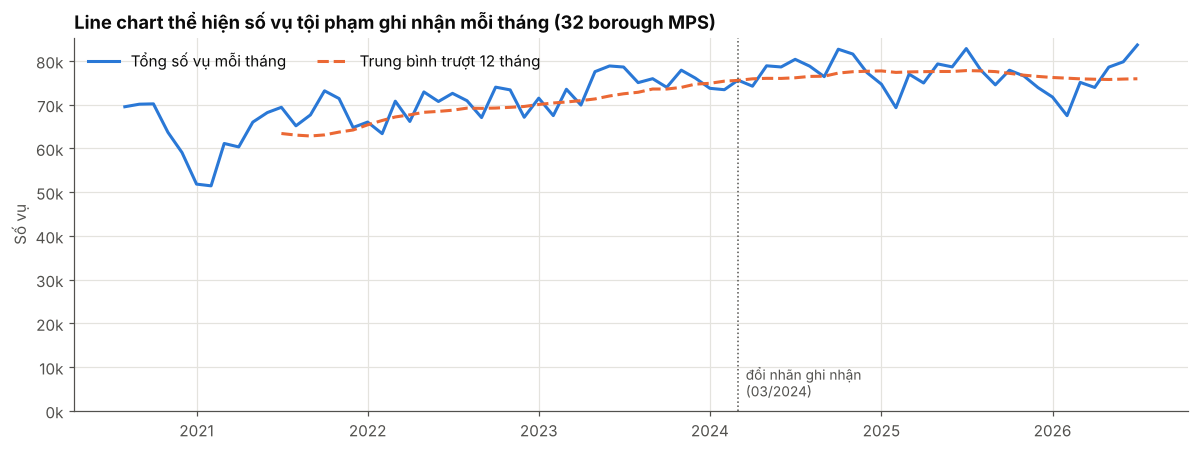

In [33]:
london = monthly.groupby('month', as_index=False).crime_count.sum()
london['ma12'] = london.crime_count.rolling(12).mean()

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(london.month, london.crime_count, color=BLUE, lw=2, label='Tổng số vụ mỗi tháng')
ax.plot(london.month, london.ma12, color=ORANGE, lw=2, ls='--', label='Trung bình trượt 12 tháng')
ax.axvline(pd.Timestamp('2024-03-01'), color=MUTED, lw=1, ls=':')
ax.text(pd.Timestamp('2024-03-01'), 0.03, '  đổi nhãn ghi nhận\n  (03/2024)', transform=ax.get_xaxis_transform(),
        color=MUTED, fontsize=9, va='bottom')
ax.set_ylim(0); ax.yaxis.set_major_formatter(thousands)
ax.set(title='Line chart thể hiện số vụ tội phạm ghi nhận mỗi tháng (32 borough MPS)', xlabel='', ylabel='Số vụ')
ax.legend(frameon=False, loc='upper left', ncols=2)
plt.tight_layout(); 
plt.show()

In [34]:
trough, peak = london.loc[london.crime_count.idxmin()], london.loc[london.crime_count.idxmax()]
ma_first, ma_last, ma_prev = london.dropna(subset=['ma12']).iloc[0], london.iloc[-1], london.ma12.iloc[-13]
l12, p12 = london.crime_count.iloc[-12:].sum(), london.crime_count.iloc[-24:-12].sum()
cut = pd.Timestamp('2024-03-01')
before = london[london.month < cut].crime_count.iloc[-6:].mean()
after = london[london.month >= cut].crime_count.iloc[:6].mean()
step = pct(after, before)
resid_sd = ((london.crime_count / london.ma12 - 1).dropna()).std() * 100   # độ lệch từng tháng so với đường nền
insight(
    f'**Đáy** vào {trough.month:%m/%Y}: {int(trough.crime_count):,} vụ, thấp hơn đỉnh {abs(pct(trough.crime_count, peak.crime_count)):.0f}% '
    f'(đỉnh {peak.month:%m/%Y}: {int(peak.crime_count):,} vụ). Đáy rơi vào đầu 2021.',
    f'**Xu hướng nền** (đường cam): trung bình trượt 12 tháng tăng từ {ma_first.ma12:,.0f} ({ma_first.month:%m/%Y}) lên {ma_last.ma12:,.0f} ({ma_last.month:%m/%Y}), '
    f'tức {pct(ma_last.ma12, ma_first.ma12):+.1f}%; trong 12 tháng gần nhất đường này gần như đi ngang ({pct(ma_last.ma12, ma_prev):+.1f}%).',
    f'**12 tháng gần nhất so với 12 tháng trước:** {int(l12):,} vs {int(p12):,} vụ ({pct(l12, p12):+.1f}%).',
    f'**Quanh mốc 03/2024:** trung bình 6 tháng trước {before:,.0f} vs 6 tháng sau {after:,.0f} vụ/tháng ({step:+.1f}%) — '
    + ('không thấy bước nhảy bất thường ở cấp tổng, nên việc đổi nhãn ghi nhận ít ảnh hưởng tổng số vụ.' if abs(step) < 5
       else 'có chênh lệch đáng kể, cần thận trọng khi so sánh hai giai đoạn.'),
    f'**Ứng dụng:** dùng đường xu hướng nền (không phải từng tháng) khi đánh giá tăng/giảm — từng tháng thường lệch khoảng ±{resid_sd:.0f}% (1 độ lệch chuẩn) so với đường nền, nên một tháng tăng/giảm nhẹ chưa phải tín hiệu.',
)

**Insight**

- **Đáy** vào 02/2021: 51,448 vụ, thấp hơn đỉnh 39% (đỉnh 07/2026: 83,664 vụ). Đáy rơi vào đầu 2021.
- **Xu hướng nền** (đường cam): trung bình trượt 12 tháng tăng từ 63,418 (07/2021) lên 75,936 (07/2026), tức +19.7%; trong 12 tháng gần nhất đường này gần như đi ngang (-2.4%).
- **12 tháng gần nhất so với 12 tháng trước:** 911,232 vs 933,683 vụ (-2.4%).
- **Quanh mốc 03/2024:** trung bình 6 tháng trước 75,185 vs 6 tháng sau 77,765 vụ/tháng (+3.4%) — không thấy bước nhảy bất thường ở cấp tổng, nên việc đổi nhãn ghi nhận ít ảnh hưởng tổng số vụ.
- **Ứng dụng:** dùng đường xu hướng nền (không phải từng tháng) khi đánh giá tăng/giảm — từng tháng thường lệch khoảng ±5% (1 độ lệch chuẩn) so với đường nền, nên một tháng tăng/giảm nhẹ chưa phải tín hiệu.

### 5.2 Horizontal bar chart — xếp hạng borough theo tỷ lệ vụ / 1.000 dân (12 tháng gần nhất)

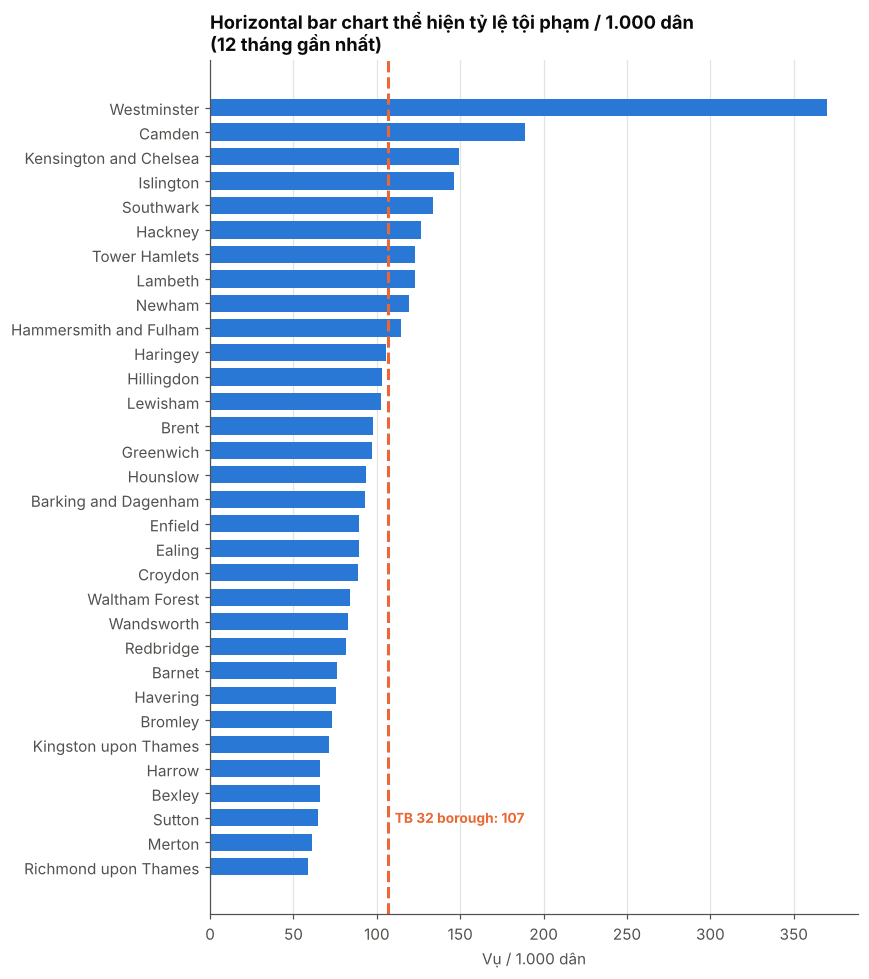

In [35]:
rank = (monthly[monthly.month == latest][['borough_name', 'rolling_12_rate']]
        .sort_values('rolling_12_rate'))
mean_rate = rank.rolling_12_rate.mean()

fig, ax = plt.subplots(figsize=(8, 9))
ax.barh(rank.borough_name, rank.rolling_12_rate, color=BLUE, height=.7)
ax.axvline(mean_rate, color=ORANGE, lw=2, ls='--')
ax.text(mean_rate + 4, 2, f'TB {len(rank)} borough: {mean_rate:,.0f}', color=ORANGE, va='center', fontsize=9, fontweight='bold')
ax.set(title='Horizontal bar chart thể hiện tỷ lệ tội phạm / 1.000 dân\n(12 tháng gần nhất)', xlabel='Vụ / 1.000 dân', ylabel='')
ax.grid(axis='y', visible=False)
plt.tight_layout(); plt.show()

In [36]:
hi, lo = rank.iloc[-1], rank.iloc[0]
top5 = ', '.join(f'{b} ({v:,.0f})' for b, v in rank.iloc[::-1].head(5).itertuples(index=False))
mean_ex = rank[rank.borough_name != hi.borough_name].rolling_12_rate.mean()
insight(
    f'**Top 5:** {top5} vụ/1.000 dân. **Thấp nhất:** {lo.borough_name} ({lo.rolling_12_rate:,.0f}).',
    f'**{hi.borough_name}** cao gấp {hi.rolling_12_rate / mean_rate:.1f} lần trung bình {len(rank)} borough ({mean_rate:,.0f}) và gấp {hi.rolling_12_rate / lo.rolling_12_rate:.1f} lần {lo.borough_name}.',
    f'Phân phối **lệch phải**: chỉ {int((rank.rolling_12_rate > mean_rate).sum())}/{len(rank)} borough nằm trên mức trung bình; trung vị {rank.rolling_12_rate.median():,.0f}, '
    f'còn nếu bỏ {hi.borough_name} thì trung bình giảm còn {mean_ex:,.0f}. Một borough ngoại lệ kéo cả mốc tham chiếu lên.',
    f'**Cẩn trọng:** tỷ lệ chia cho dân số *thường trú* theo Census 2021. Các borough trung tâm đông khách / người đi làm ban ngày như Westminster, Camden, Kensington and Chelsea… bị thổi phồng; so sánh với nhóm borough ngoại thành có thể không công bằng.',
)

**Insight**

- **Top 5:** Westminster (370), Camden (189), Kensington and Chelsea (149), Islington (146), Southwark (134) vụ/1.000 dân. **Thấp nhất:** Richmond upon Thames (59).
- **Westminster** cao gấp 3.5 lần trung bình 32 borough (107) và gấp 6.3 lần Richmond upon Thames.
- Phân phối **lệch phải**: chỉ 10/32 borough nằm trên mức trung bình; trung vị 93, còn nếu bỏ Westminster thì trung bình giảm còn 98. Một borough ngoại lệ kéo cả mốc tham chiếu lên.
- **Cẩn trọng:** tỷ lệ chia cho dân số *thường trú* theo Census 2021. Các borough trung tâm đông khách / người đi làm ban ngày như Westminster, Camden, Kensington and Chelsea… bị thổi phồng; so sánh với nhóm borough ngoại thành có thể không công bằng.

### 5.3 Boxplot — phân phối theo nhóm tội phạm
Mỗi điểm dữ liệu là một cặp *(borough, tháng)*; thang **log** vì các nhóm chênh nhau hàng chục lần (bỏ giá trị 0 để vẽ log). Các nhóm không đủ số liệu (xem lưu ý ở đầu mục 5) bị loại.

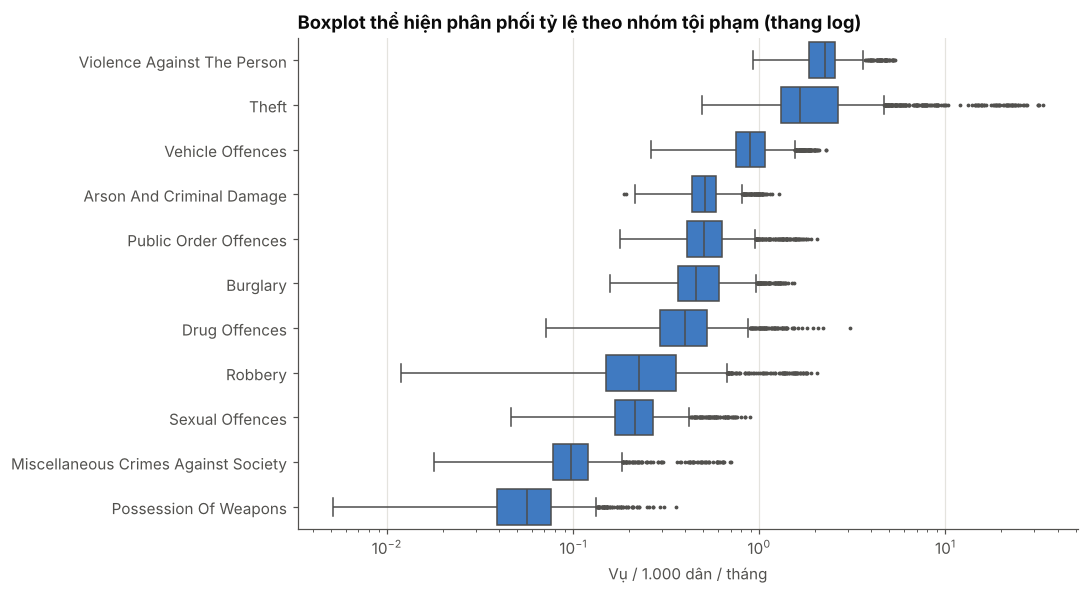

In [37]:
grp = (facts_borough.groupby(['crime_group', 'borough_name', 'month'], as_index=False)
       .agg(crime_count=('crime_count', 'sum'), population_2021=('population_2021', 'first')))
grp['rate_per_1000'] = ratio(grp.crime_count, grp.population_2021, 1000)
plot_grp = grp[(grp.rate_per_1000 > 0) & ~grp.crime_group.isin(MINOR)]   # bỏ giá trị 0 (log) và nhóm gần như không có số liệu
order = plot_grp.groupby('crime_group').rate_per_1000.median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.boxplot(data=plot_grp, y='crime_group', x='rate_per_1000', order=order, color=BLUE, fliersize=1.5,
            linewidth=1, flierprops={'markerfacecolor': MUTED, 'markeredgecolor': MUTED}, ax=ax)
ax.set_xscale('log')
ax.set(title='Boxplot thể hiện phân phối tỷ lệ theo nhóm tội phạm (thang log)', xlabel='Vụ / 1.000 dân / tháng', ylabel='')
ax.set_yticks(range(len(order)), [s.title() for s in order])
ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.show()

In [38]:
med = plot_grp.groupby('crime_group').rate_per_1000.median().sort_values(ascending=False)
spread = plot_grp.groupby('crime_group').rate_per_1000.agg(lambda s: s.max() / s.median()).sort_values(ascending=False)
widest = spread.index[0]
extreme = plot_grp[plot_grp.crime_group == widest].nlargest(1, 'rate_per_1000').iloc[0]
insight(
    f'**Nhóm phổ biến nhất** (theo trung vị): {med.index[0].title()} ({med.iloc[0]:.2f}) và {med.index[1].title()} ({med.iloc[1]:.2f}) vụ/1.000 dân/tháng — '
    f'gấp khoảng {med.iloc[0] / med.iloc[-1]:.0f} lần nhóm ít nhất ({med.index[-1].title()}, {med.iloc[-1]:.3f}).',
    f'**{widest.title()}** có độ phân tán lớn nhất: giá trị cực đại gấp {spread.iloc[0]:.0f} lần trung vị của chính nhóm, '
    f'điểm cực trị là {extreme.borough_name} {extreme.month:%m/%Y} ({extreme.rate_per_1000:.1f}). Hộp rộng + nhiều điểm outlier bên phải = mức độ phụ thuộc mạnh vào địa bàn.',
    f'Các nhóm như {med.index[2].title()}, {med.index[3].title()} có hộp hẹp: mức độ tương đối **đồng đều** giữa các borough và các tháng.',
    '**Ứng dụng:** nhóm hộp rộng cần phân tích theo địa bàn bằng drill-down; nhóm hộp hẹp phù hợp theo dõi bằng trung bình toàn thành phố.',
)

**Insight**

- **Nhóm phổ biến nhất** (theo trung vị): Violence Against The Person (2.26) và Theft (1.65) vụ/1.000 dân/tháng — gấp khoảng 40 lần nhóm ít nhất (Possession Of Weapons, 0.056).
- **Theft** có độ phân tán lớn nhất: giá trị cực đại gấp 20 lần trung vị của chính nhóm, điểm cực trị là Westminster 12/2024 (33.2). Hộp rộng + nhiều điểm outlier bên phải = mức độ phụ thuộc mạnh vào địa bàn.
- Các nhóm như Vehicle Offences, Arson And Criminal Damage có hộp hẹp: mức độ tương đối **đồng đều** giữa các borough và các tháng.
- **Ứng dụng:** nhóm hộp rộng cần phân tích theo địa bàn bằng drill-down; nhóm hộp hẹp phù hợp theo dõi bằng trung bình toàn thành phố.

### 5.4 Heatmap — borough × nhóm tội phạm
Chỉ số = tỷ lệ của borough ÷ **trung bình 32 borough** cùng nhóm (12 tháng gần nhất); ô trắng = không có bản ghi; màu bị chặn ở 3×. `1` = bằng trung bình; cam > 1 (cao hơn), xanh < 1 (thấp hơn). Cách này cho thấy borough nổi bật ở nhóm *nào*, không bị nhóm đông vụ lấn át.

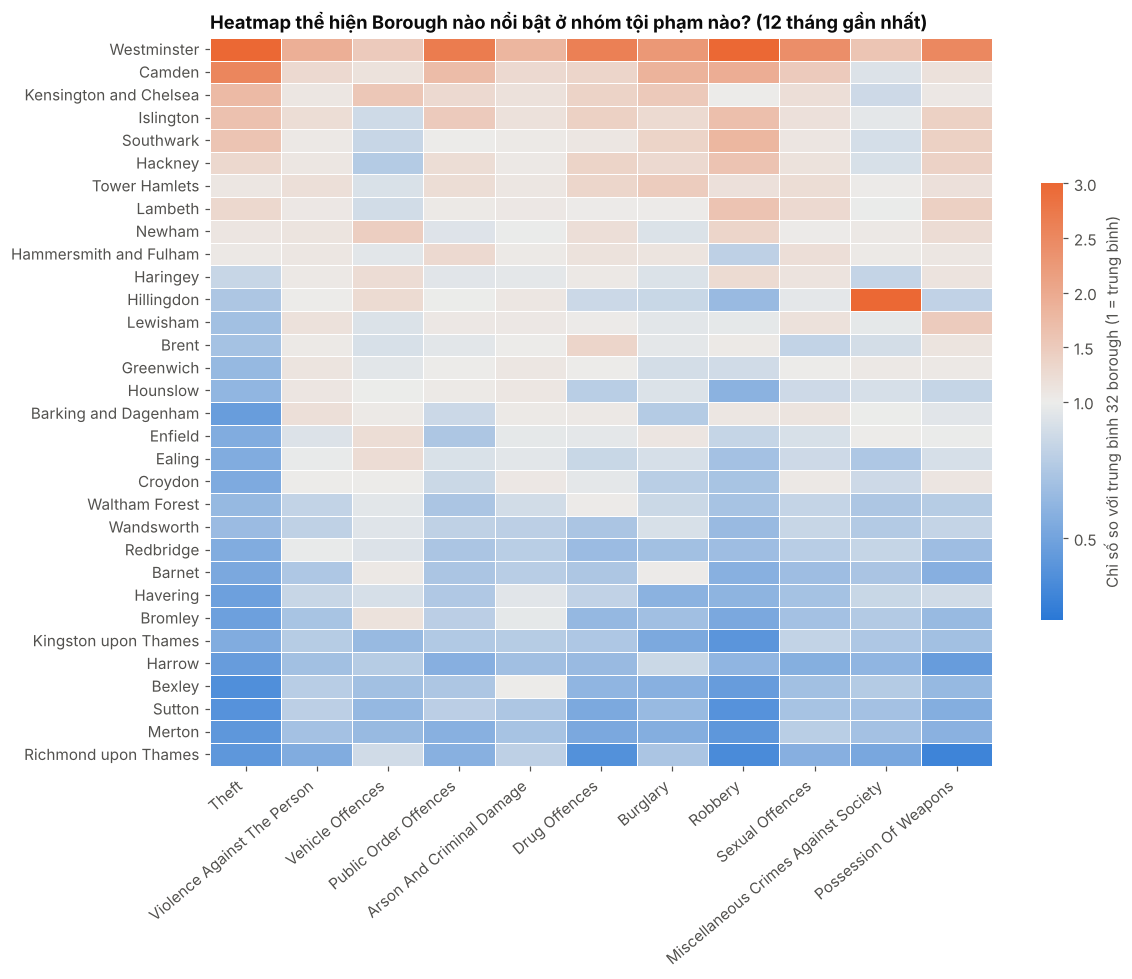

In [39]:
g12 = (facts_borough[facts_borough.month.isin(last12)]
       .groupby(['borough_name', 'crime_group']).crime_count.sum().unstack('crime_group'))
pop = dim_borough.set_index('borough_name').population_2021
rate12 = g12.drop(columns=MINOR, errors='ignore').div(pop, axis=0) * 1000   # bỏ nhóm gần như không có số liệu (NFIB Fraud, Fraud and Forgery)
index = rate12 / rate12.mean()
index = index.loc[rate12.sum(axis=1).sort_values(ascending=False).index,
                  rate12.mean().sort_values(ascending=False).index]

cmap = mcolors.LinearSegmentedColormap.from_list('div', [BLUE, '#ececea', ORANGE])
norm = mcolors.TwoSlopeNorm(vcenter=1, vmin=0.2, vmax=3)
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(index, cmap=cmap, norm=norm, linewidths=.5, linecolor='white', ax=ax,
            cbar_kws={'label': 'Chỉ số so với trung bình 32 borough (1 = trung bình)', 'shrink': .6})
ax.set_xticklabels([s.title() for s in index.columns], rotation=40, ha='right')
ax.set(title='Heatmap thể hiện Borough nào nổi bật ở nhóm tội phạm nào? (12 tháng gần nhất)', xlabel='', ylabel='')
ax.grid(False)
plt.tight_layout()
plt.show()

In [40]:
cells = index.stack().sort_values(ascending=False)
top_cells = ', '.join(f'{b} – {g.title()} ({v:.1f}×)' for (b, g), v in cells.head(4).items())
most_var = index.std().idxmax()                                   # nhóm phân hoá mạnh nhất giữa các borough
lead = index.idxmax(axis=0).value_counts()                      # borough dẫn đầu ở bao nhiêu nhóm
n_above = (index > 1).sum(axis=1).sort_values(ascending=False)
low_boroughs = ', '.join(n_above[n_above <= 1].index.tolist()) or '(không có)'
insight(
    f'**Ô nổi bật nhất:** {top_cells}.',
    f'**{lead.index[0]}** dẫn đầu ở {lead.iloc[0]}/{index.shape[1]} nhóm tội phạm, cho thấy mức cao của borough này **không phải do một nhóm riêng lẻ** mà trải rộng nhiều loại tội phạm.',
    f'**{n_above.index[0]}** vượt trung bình ở {n_above.iloc[0]}/{index.shape[1]} nhóm; ngược lại các borough chỉ vượt trung bình ở tối đa 1 nhóm: {low_boroughs} — nhìn trên heatmap là các hàng gần như toàn xanh.',
    f'Nhóm **{most_var.title()}** phân hoá mạnh nhất giữa các borough (độ lệch chuẩn của chỉ số = {index[most_var].std():.2f}, cao nhất trong {index.shape[1]} nhóm): đây là loại tội phạm tạo ra khác biệt lớn nhất giữa các địa bàn.',
    '**Ứng dụng:** dùng chỉ số này để ưu tiên nguồn lực theo *loại* tội phạm thay vì chỉ theo tổng số vụ; ô cam đậm nhưng số vụ tuyệt đối nhỏ cần kiểm tra thêm trước khi kết luận.',
)

**Insight**

- **Ô nổi bật nhất:** Westminster – Theft (6.2×), Hillingdon – Miscellaneous Crimes Against Society (4.7×), Westminster – Robbery (3.8×), Westminster – Public Order Offences (2.7×).
- **Westminster** dẫn đầu ở 9/11 nhóm tội phạm, cho thấy mức cao của borough này **không phải do một nhóm riêng lẻ** mà trải rộng nhiều loại tội phạm.
- **Westminster** vượt trung bình ở 11/11 nhóm; ngược lại các borough chỉ vượt trung bình ở tối đa 1 nhóm: Ealing, Waltham Forest, Bexley, Bromley, Redbridge, Wandsworth, Kingston upon Thames, Havering, Harrow, Sutton, Merton, Richmond upon Thames — nhìn trên heatmap là các hàng gần như toàn xanh.
- Nhóm **Theft** phân hoá mạnh nhất giữa các borough (độ lệch chuẩn của chỉ số = 1.08, cao nhất trong 11 nhóm): đây là loại tội phạm tạo ra khác biệt lớn nhất giữa các địa bàn.
- **Ứng dụng:** dùng chỉ số này để ưu tiên nguồn lực theo *loại* tội phạm thay vì chỉ theo tổng số vụ; ô cam đậm nhưng số vụ tuyệt đối nhỏ cần kiểm tra thêm trước khi kết luận.

### 5.5 Scatter plot — nhân lực vs tỷ lệ tội phạm
Mỗi chấm là một borough: trục x = FTE ward officer / 10.000 dân (trung bình 12 tháng gần nhất), trục y = tỷ lệ 12 tháng gần nhất. Borough thiếu FTE (không điền số) bị bỏ khỏi biểu đồ.

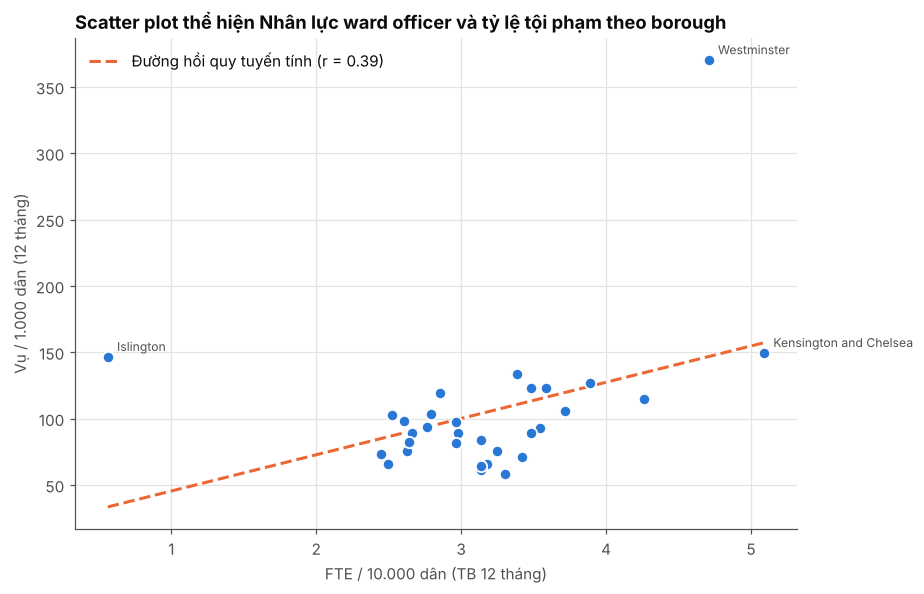

In [41]:
sc = (monthly_master[monthly_master.month.isin(last12)]
      .groupby('borough_name', as_index=False)
      .agg(officers_per_10000=('officers_per_10000', 'mean'), rolling_12_rate=('rolling_12_rate', 'last')))
dropped = sc[sc.officers_per_10000.isna()].borough_name.tolist()
sc = sc.dropna()
slope, intercept = np.polyfit(sc.officers_per_10000, sc.rolling_12_rate, 1)
r = sc.officers_per_10000.corr(sc.rolling_12_rate)

fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.scatter(sc.officers_per_10000, sc.rolling_12_rate, s=55, color=BLUE, edgecolor='white', linewidth=1.2, zorder=3)
xs = np.linspace(sc.officers_per_10000.min(), sc.officers_per_10000.max(), 50)
ax.plot(xs, slope * xs + intercept, color=ORANGE, lw=2, ls='--', label=f'Đường hồi quy tuyến tính (r = {r:.2f})')
for _, row in pd.concat([sc.nlargest(3, 'rolling_12_rate'), sc.nlargest(2, 'officers_per_10000')]).drop_duplicates().iterrows():
    ax.annotate(row.borough_name, (row.officers_per_10000, row.rolling_12_rate), xytext=(6, 4),
                textcoords='offset points', fontsize=8, color=MUTED)
ax.set(title='Scatter plot thể hiện Nhân lực ward officer và tỷ lệ tội phạm theo borough',
       xlabel='FTE / 10.000 dân (TB 12 tháng)', ylabel='Vụ / 1.000 dân (12 tháng)')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

In [42]:
rho = sc.officers_per_10000.corr(sc.rolling_12_rate, method='spearman')
hi_rate = sc.loc[sc.rolling_12_rate.idxmax(), 'borough_name']
lo_fte = sc.loc[sc.officers_per_10000.idxmin(), 'borough_name']
sub1 = sc[sc.borough_name != hi_rate]
sub2 = sub1[sub1.borough_name != lo_fte]
r1 = sub1.officers_per_10000.corr(sub1.rolling_12_rate)
r2 = sub2.officers_per_10000.corr(sub2.rolling_12_rate)
insight(
    f'**Tương quan dương yếu–vừa:** Pearson r = {r:.2f}, Spearman ρ = {rho:.2f} trên {len(sc)} borough (bỏ {", ".join(dropped)} do thiếu FTE, không điền số).',
    f'**Bị chi phối bởi outlier:** {hi_rate} (tỷ lệ cao nhất) và {lo_fte} (ít FTE nhất) kéo đường hồi quy; bỏ {hi_rate} thì r = {r1:.2f}, bỏ cả {lo_fte} thì r = {r2:.2f}.',
    'Chiều **dương** nơi tội phạm cao được bố trí thêm lực lượng hoặc do cả hai cùng tăng theo mật độ dân cư / khách ban ngày.',
    '**Kết luận:** biểu đồ chỉ mô tả mối liên hệ; muốn đánh giá hiệu quả cần kiểm soát thêm yếu tố (dân số ban ngày, thu nhập, thời điểm triển khai).',
)

**Insight**

- **Tương quan dương yếu–vừa:** Pearson r = 0.39, Spearman ρ = 0.33 trên 31 borough (bỏ Camden do thiếu FTE, không điền số).
- **Bị chi phối bởi outlier:** Westminster (tỷ lệ cao nhất) và Islington (ít FTE nhất) kéo đường hồi quy; bỏ Westminster thì r = 0.15, bỏ cả Islington thì r = 0.55.
- Chiều **dương** nơi tội phạm cao được bố trí thêm lực lượng hoặc do cả hai cùng tăng theo mật độ dân cư / khách ban ngày.
- **Kết luận:** biểu đồ chỉ mô tả mối liên hệ; muốn đánh giá hiệu quả cần kiểm soát thêm yếu tố (dân số ban ngày, thu nhập, thời điểm triển khai).

### 5.6 Histogram + KDE — phân phối tỷ lệ theo tháng

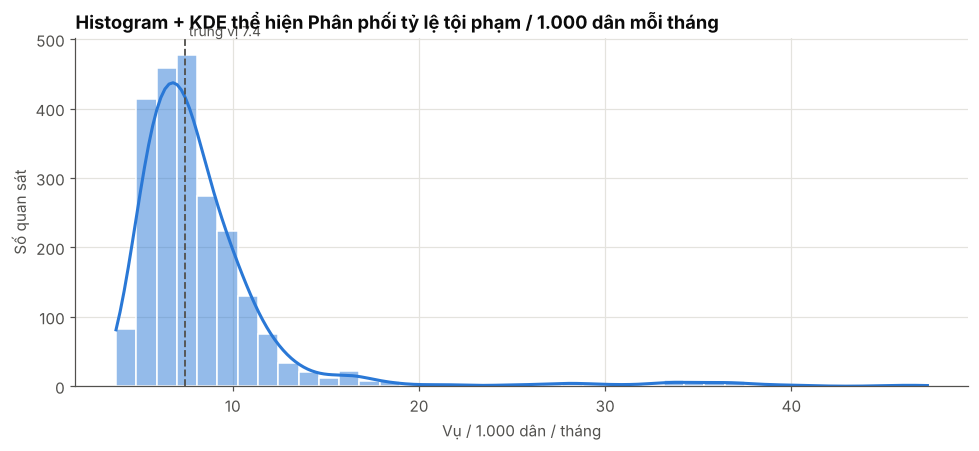

In [43]:
vals = monthly.rate_per_1000.dropna()
fig, ax = plt.subplots(figsize=(9, 4.2))
sns.histplot(vals, bins=40, kde=True, color=BLUE, edgecolor='white', line_kws={'color': ORANGE, 'lw': 2}, ax=ax)
ax.axvline(vals.median(), color=MUTED, ls='--', lw=1.2)
ax.text(vals.median(), 1.005, f' trung vị {vals.median():.1f}', color=MUTED, transform=ax.get_xaxis_transform(), fontsize=9)
ax.set(title='Histogram + KDE thể hiện Phân phối tỷ lệ tội phạm / 1.000 dân mỗi tháng', xlabel='Vụ / 1.000 dân / tháng', ylabel='Số quan sát')
plt.tight_layout()
plt.show()

In [44]:
q = vals.quantile([.5, .9, .99])
thr95 = vals.quantile(.95)
top5 = monthly.loc[monthly.rate_per_1000 >= thr95, 'borough_name'].value_counts(normalize=True)
n_out = int(monthly.outlier_iqr.sum())
insight(
    f'**Lệch phải rõ rệt:** trung bình {vals.mean():.1f} > trung vị {q[.5]:.1f}; 90% quan sát ≤ {q[.9]:.1f}, 99% ≤ {q[.99]:.1f}, cực đại {vals.max():.1f} vụ/1.000 dân/tháng.',
    f'**Đuôi phải do một vài địa bàn:** trong 5% quan sát cao nhất, {top5.index[0]} chiếm {top5.iloc[0] * 100:.0f}%'
    + (f' và {top5.index[1]} {top5.iloc[1] * 100:.0f}%.' if len(top5) > 1 else '.'),
    f'**Outlier:** phương pháp IQR theo *từng borough* chỉ gắn cờ {n_out}/{len(monthly)} tháng-borough ({n_out / len(monthly) * 100:.1f}%) vì mỗi borough được so với chính lịch sử của nó; '
    'các giá trị này là số đếm thật nên **được giữ lại**, chỉ gắn cờ `outlier_iqr`.',
    '**Hệ quả cho mô hình:** phân phối lệch nên dùng trung vị / log khi mô tả, và cẩn trọng với hồi quy tuyến tính nhạy với outlier.',
)

**Insight**

- **Lệch phải rõ rệt:** trung bình 8.5 > trung vị 7.4; 90% quan sát ≤ 11.5, 99% ≤ 35.0, cực đại 47.3 vụ/1.000 dân/tháng.
- **Đuôi phải do một vài địa bàn:** trong 5% quan sát cao nhất, Westminster chiếm 59% và Camden 37%.
- **Outlier:** phương pháp IQR theo *từng borough* chỉ gắn cờ 54/2304 tháng-borough (2.3%) vì mỗi borough được so với chính lịch sử của nó; các giá trị này là số đếm thật nên **được giữ lại**, chỉ gắn cờ `outlier_iqr`.
- **Hệ quả cho mô hình:** phân phối lệch nên dùng trung vị / log khi mô tả, và cẩn trọng với hồi quy tuyến tính nhạy với outlier.

### 5.7 Treemap — cơ cấu nhóm và phân nhóm tội phạm (12 tháng gần nhất)
Diện tích mỗi ô tỷ lệ với số vụ. Ô lớn là **nhóm** (màu riêng), ô nhỏ bên trong là **phân nhóm**. Bảy nhóm lớn nhất có màu cố định, các nhóm còn lại màu xám. Thuật toán *squarified treemap* được viết trực tiếp bằng Matplotlib, không cần cài thêm thư viện.

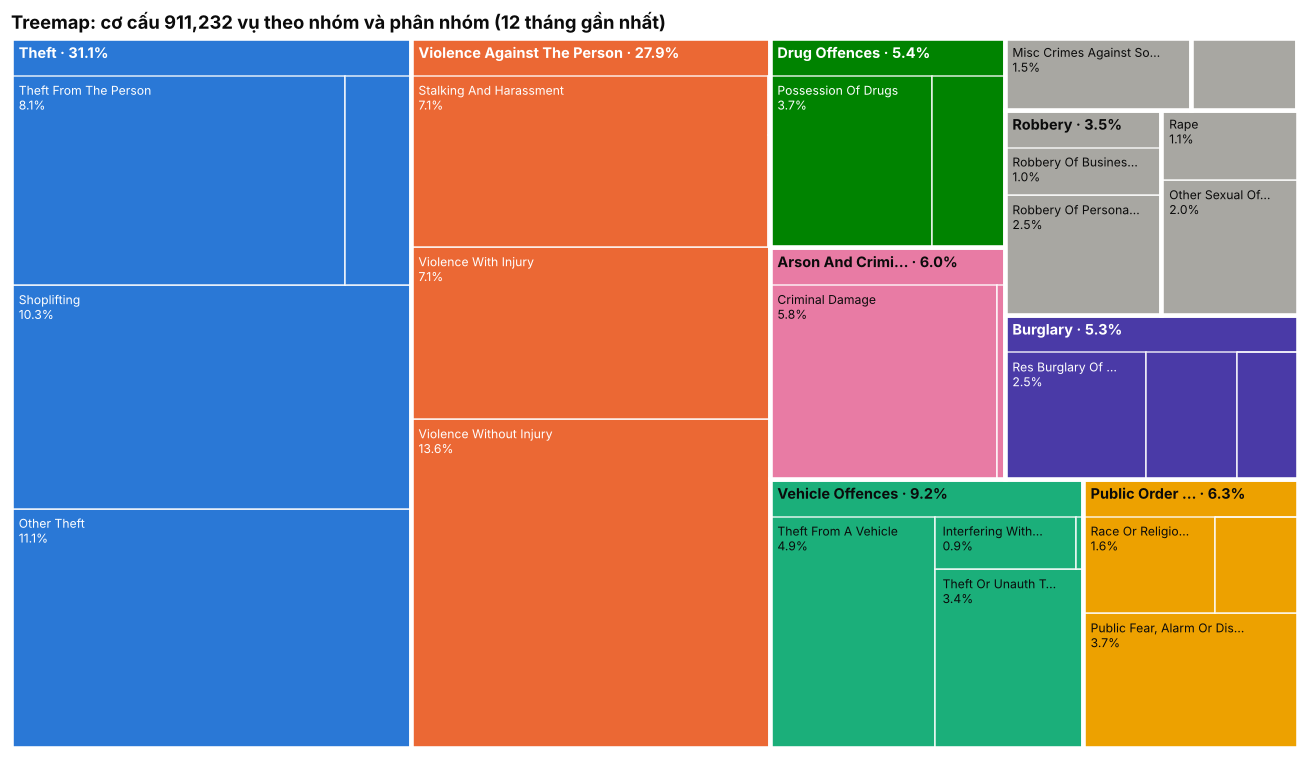

In [45]:
import matplotlib.patches as mpatches

CATEGORICAL = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7']
OTHER_GRAY = '#a8a7a2'
DARK_TEXT = {'#1baf7a', '#eda100', '#e87ba4', OTHER_GRAY}          # nền sáng → chữ tối cho dễ đọc


def squarify(values, x, y, w, h):
    """Squarified treemap (Bruls et al., 2000). values đã sắp giảm dần; trả về [(x, y, w, h), ...] cùng thứ tự."""
    total = sum(values)
    areas = [v * w * h / total for v in values]
    rects = []

    def worst(row, side):
        s = sum(row)
        return max(max(side ** 2 * r / s ** 2, s ** 2 / (side ** 2 * r)) for r in row)

    def place(row, x, y, w, h):
        s = sum(row)
        if w >= h:                                   # xếp một cột dọc bên trái
            cw, cy = s / h, y
            for a in row:
                rects.append((x, cy, cw, a / cw)); cy += a / cw
            return x + cw, y, w - cw, h
        rh, cx = s / w, x                            # xếp một hàng ngang phía dưới
        for a in row:
            rects.append((cx, y, a / rh, rh)); cx += a / rh
        return x, y + rh, w, h - rh

    row = []
    for a in areas:
        side = min(w, h)
        if not row or worst(row + [a], side) <= worst(row, side):
            row.append(a)
        else:
            x, y, w, h = place(row, x, y, w, h)
            row = [a]
    if row:
        place(row, x, y, w, h)
    return rects


tm = (facts_borough[facts_borough.month.isin(last12)]
      .groupby(['crime_group', 'crime_subgroup']).crime_count.sum().loc[lambda s: s > 0])
groups = tm.groupby(level=0).sum().sort_values(ascending=False)
group_color = {g: (CATEGORICAL[i] if i < len(CATEGORICAL) else OTHER_GRAY) for i, g in enumerate(groups.index)}
total12 = int(groups.sum())

fig, ax = plt.subplots(figsize=(12, 7))
W_, H_ = 100, 60
for (gx, gy, gw, gh), group in zip(squarify(groups.tolist(), 0, 0, W_, H_), groups.index):
    color = group_color[group]
    ink = INK if color in DARK_TEXT else 'white'
    subs = tm.loc[group].sort_values(ascending=False)
    head = 3.2 if gh > 8 and gw > 12 else 0                         # chừa chỗ ghi tên nhóm
    ax.add_patch(mpatches.Rectangle((gx, gy), gw, gh, facecolor=color, edgecolor='none'))   # nền dải tên nhóm
    for (sx, sy, sw, sh), (sub, n) in zip(squarify(subs.tolist(), gx, gy, gw, gh - head), subs.items()):
        ax.add_patch(mpatches.Rectangle((sx, sy), sw, sh, facecolor=color, edgecolor='white', linewidth=1, alpha=.85))
        if sw > 10 and sh > 4:                                         # chỉ ghi nhãn ô đủ lớn
            limit = int(sw * 1.6)
            name = sub.title() if len(sub) <= limit else sub.title()[:limit - 1] + '…'
            ax.text(sx + .6, sy + sh - .6, f'{name}\n{n / total12:.1%}', va='top', ha='left', fontsize=8, color=ink)
    ax.add_patch(mpatches.Rectangle((gx, gy), gw, gh, fill=False, edgecolor='white', linewidth=3))
    if head:
        label = f'{group.title()} · {groups[group] / total12:.1%}'
        if len(label) > gw * 1.3:
            label = f'{group.title()[:int(gw * 1.3) - 8]}… · {groups[group] / total12:.1%}'
        ax.text(gx + .6, gy + gh - .5, label, va='top', ha='left',
                fontsize=9.5, fontweight='bold', color=ink)
ax.set_xlim(0, W_); ax.set_ylim(0, H_); ax.axis('off')
ax.set_title(f'Treemap: cơ cấu {total12:,} vụ theo nhóm và phân nhóm (12 tháng gần nhất)')
plt.tight_layout(); plt.show()

In [46]:
top_sub = tm.sort_values(ascending=False)
top3 = ', '.join(f'{s.title()} ({g.title()}, {n / total12:.1%})' for (g, s), n in top_sub.head(3).items())
theft_subs = tm.loc['THEFT'].sort_values(ascending=False) if 'THEFT' in groups.index else None
cum = groups.cumsum() / total12
n_half = int((cum < .5).sum() + 1)
insight(
    f'**Ba phân nhóm lớn nhất:** {top3} — riêng ba ô này đã chiếm {top_sub.head(3).sum() / total12:.0%} tổng số vụ.',
    f'**Tập trung cao:** chỉ {n_half} nhóm đầu ({", ".join(g.title() for g in groups.index[:n_half])}) đã chiếm hơn một nửa số vụ; '
    f'{len(groups) - n_half} nhóm còn lại xếp thành các ô nhỏ dần.',
    (f'**Bên trong Theft:** {theft_subs.index[0].title()} chiếm {theft_subs.iloc[0] / theft_subs.sum():.0%} số vụ trộm cắp, '
     f'tiếp theo là {theft_subs.index[1].title()} ({theft_subs.iloc[1] / theft_subs.sum():.0%}).') if theft_subs is not None else '',
    '**Ứng dụng:** treemap cho thấy cả cấp nhóm lẫn phân nhóm trong một hình — phù hợp làm điểm vào drill-down trên dashboard.',
)

**Insight**

- **Ba phân nhóm lớn nhất:** Violence Without Injury (Violence Against The Person, 13.6%), Other Theft (Theft, 11.1%), Shoplifting (Theft, 10.3%) — riêng ba ô này đã chiếm 35% tổng số vụ.
- **Tập trung cao:** chỉ 2 nhóm đầu (Theft, Violence Against The Person) đã chiếm hơn một nửa số vụ; 10 nhóm còn lại xếp thành các ô nhỏ dần.
- **Bên trong Theft:** Other Theft chiếm 36% số vụ trộm cắp, tiếp theo là Shoplifting (33%).
- **Ứng dụng:** treemap cho thấy cả cấp nhóm lẫn phân nhóm trong một hình — phù hợp làm điểm vào drill-down trên dashboard.

### 5.8 Choropleth map — tỷ lệ tội phạm theo borough (12 tháng gần nhất)
Ranh giới đọc trực tiếp từ shapefile LSOA 2021 trong `data/raw`, gộp (dissolve) theo borough. Màu càng đậm tỷ lệ vụ / 1.000 dân càng cao. City of London nằm ngoài phạm vi MPS nên tô xám gạch chéo.

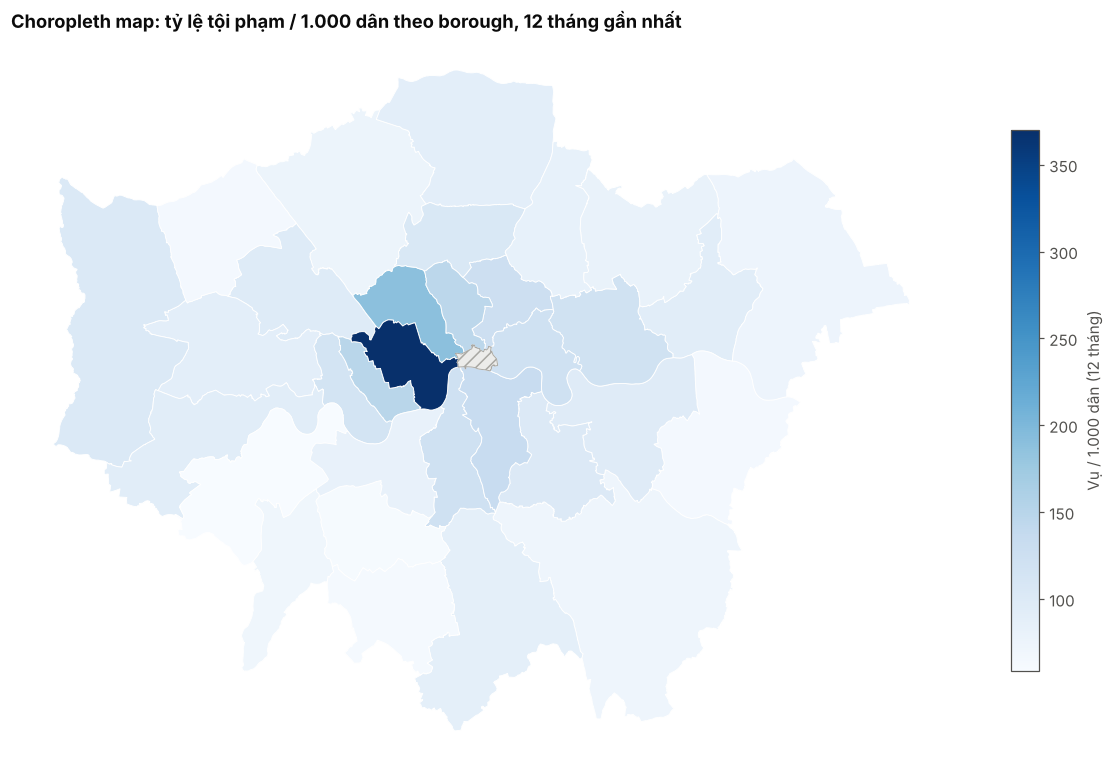

In [47]:
import geopandas as gpd

shp_files = sorted((RAW / 'boundaries' / 'LB_LSOA2021_shp' / 'LB_shp').glob('*.shp'))
parts = [gpd.read_file(p) for p in shp_files]
lsoa_geo = gpd.GeoDataFrame(pd.concat(parts, ignore_index=True), crs=parts[0].crs)
borough_geo = (lsoa_geo.dissolve(by='lad22nm', as_index=False)[['lad22nm', 'geometry']]
               .rename(columns={'lad22nm': 'borough_name'}))

rate_map = monthly[monthly.month == latest][['borough_name', 'rolling_12_rate']]
geo_rate = borough_geo.merge(rate_map, on='borough_name', how='left', validate='one_to_one')
assert geo_rate.rolling_12_rate.notna().sum() == 32, 'Có borough không khớp tên với ranh giới'

fig, ax = plt.subplots(figsize=(11, 8.5))
geo_rate.plot(column='rolling_12_rate', cmap='Blues', linewidth=.6, edgecolor='white', ax=ax, legend=True,
              legend_kwds={'label': 'Vụ / 1.000 dân (12 tháng)', 'shrink': .6},
              missing_kwds={'color': '#ececea', 'hatch': '///', 'edgecolor': '#a8a7a2', 'label': 'Ngoài phạm vi MPS'})
ax.set_axis_off()
ax.set_title('Choropleth map: tỷ lệ tội phạm / 1.000 dân theo borough, 12 tháng gần nhất')
plt.tight_layout(); plt.show()

In [48]:
# Inner London theo London Government Act 1963 (12 borough, không tính City of London)
INNER = {'Camden', 'Greenwich', 'Hackney', 'Hammersmith and Fulham', 'Islington', 'Kensington and Chelsea',
         'Lambeth', 'Lewisham', 'Southwark', 'Tower Hamlets', 'Wandsworth', 'Westminster'}
rm = rate_map.assign(zone=np.where(rate_map.borough_name.isin(INNER), 'Inner', 'Outer'))
zone_mean = rm.groupby('zone').rolling_12_rate.mean()
zone_median = rm.groupby('zone').rolling_12_rate.median()
top10_inner = int(rm.nlargest(10, 'rolling_12_rate').zone.eq('Inner').sum())
lo = rm.nsmallest(3, 'rolling_12_rate').borough_name.tolist()
insight(
    f'**Cụm trung tâm rõ rệt:** {top10_inner}/10 borough có tỷ lệ cao nhất thuộc Inner London; các ô đậm nhất liền kề nhau quanh Westminster.',
    f'**Inner vs Outer London:** trung bình {zone_mean["Inner"]:.0f} vs {zone_mean["Outer"]:.0f} vụ/1.000 dân '
    f'(trung vị {zone_median["Inner"]:.0f} vs {zone_median["Outer"]:.0f}) — gấp khoảng {zone_mean["Inner"] / zone_mean["Outer"]:.1f} lần, '
    f'kể cả khi dùng trung vị để giảm ảnh hưởng của Westminster.',
    f'**Vành đai ngoài thấp nhất:** {", ".join(lo)} — các borough ngoại ô, mật độ thương mại và du lịch thấp.',
    '**Lưu ý diễn giải:** bản đồ tô theo dân số *thường trú*; khu trung tâm đông khách và người đi làm ban ngày nên tỷ lệ bị phóng đại '
    'so với nguy cơ thực tế của một người ở đó. Nên đọc kèm bản đồ số vụ tuyệt đối trên dashboard.',
)

**Insight**

- **Cụm trung tâm rõ rệt:** 9/10 borough có tỷ lệ cao nhất thuộc Inner London; các ô đậm nhất liền kề nhau quanh Westminster.
- **Inner vs Outer London:** trung bình 146 vs 83 vụ/1.000 dân (trung vị 125 vs 83) — gấp khoảng 1.8 lần, kể cả khi dùng trung vị để giảm ảnh hưởng của Westminster.
- **Vành đai ngoài thấp nhất:** Richmond upon Thames, Merton, Sutton — các borough ngoại ô, mật độ thương mại và du lịch thấp.
- **Lưu ý diễn giải:** bản đồ tô theo dân số *thường trú*; khu trung tâm đông khách và người đi làm ban ngày nên tỷ lệ bị phóng đại so với nguy cơ thực tế của một người ở đó. Nên đọc kèm bản đồ số vụ tuyệt đối trên dashboard.

### 5.9 Pie chart — tỷ trọng các nhóm tội phạm
So sánh cơ cấu **12 tháng đầu** (08/2020–07/2021, có giai đoạn phong toả COVID-19) với **12 tháng gần nhất**. Sáu nhóm lớn nhất được tách riêng, các nhóm còn lại gộp vào "Khác" để mỗi phần đủ lớn mà đọc.

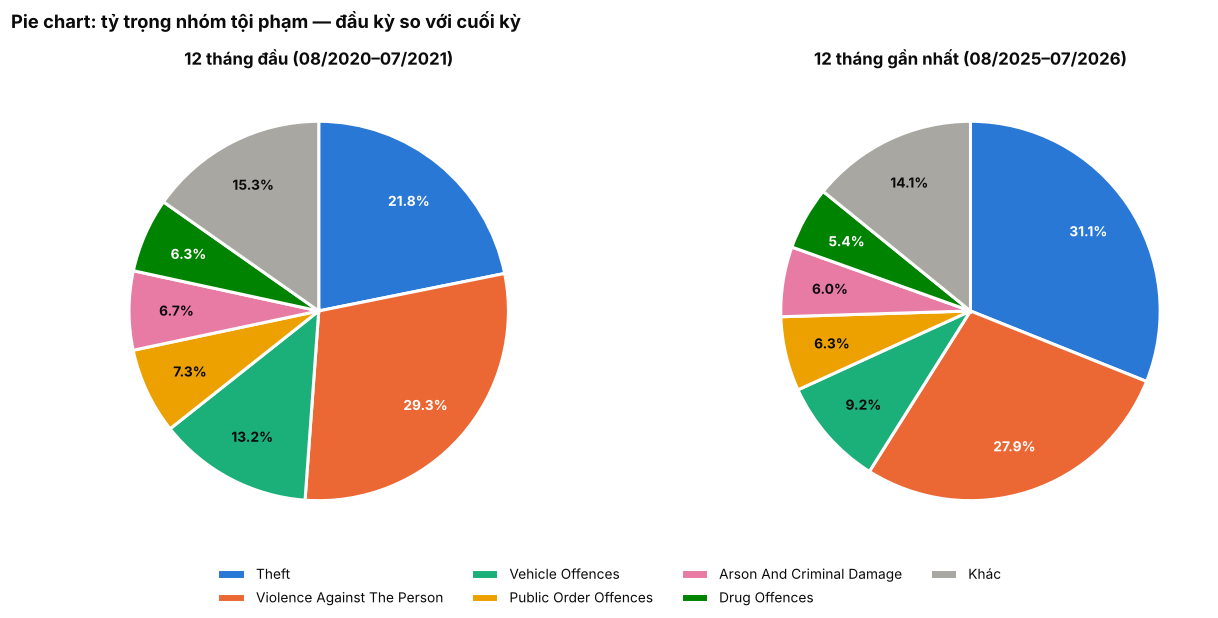

In [49]:
first12 = sorted(monthly.month.unique())[:12]


def shares(months):
    s = facts_borough[facts_borough.month.isin(months)].groupby('crime_group').crime_count.sum()
    return s / s.sum()


share_first, share_last = shares(first12), shares(last12)
keep = share_last.sort_values(ascending=False).index[:6].tolist()


def fold(s):
    out = s.reindex(keep).fillna(0)
    out['Khác'] = s.drop(index=keep, errors='ignore').sum()
    return out


pie_colors = [group_color.get(g, OTHER_GRAY) for g in keep] + [OTHER_GRAY]
fig, axes = plt.subplots(1, 2, figsize=(12, 5.6))
for ax, (title, s) in zip(axes, [(f'12 tháng đầu ({first12[0]:%m/%Y}–{first12[-1]:%m/%Y})', fold(share_first)),
                                 (f'12 tháng gần nhất ({last12[0]:%m/%Y}–{last12[-1]:%m/%Y})', fold(share_last))]):
    wedges, _, autotexts = ax.pie(s.values, colors=pie_colors, startangle=90, counterclock=False,
                                  autopct=lambda p: f'{p:.1f}%' if p >= 4 else '', pctdistance=.75,
                                  wedgeprops={'edgecolor': 'white', 'linewidth': 2})
    for t, c in zip(autotexts, pie_colors):
        t.set_color(INK if c in DARK_TEXT else 'white'); t.set_fontsize(9); t.set_fontweight('bold')
    ax.set_title(title, loc='center', fontsize=11)
fig.legend(wedges, [g.title() for g in keep] + ['Khác'], loc='lower center', ncols=4, frameon=False, fontsize=9)
fig.suptitle('Pie chart: tỷ trọng nhóm tội phạm — đầu kỳ so với cuối kỳ', fontweight='bold', x=.02, ha='left')
plt.tight_layout(rect=(0, .08, 1, 1)); plt.show()

In [50]:
delta = ((share_last - share_first.reindex(share_last.index).fillna(0)) * 100).sort_values()
up, down = delta.index[-1], delta.index[0]
top2 = share_last.sort_values(ascending=False)
insight(
    f'**Hai nhóm chiếm hơn một nửa:** {top2.index[0].title()} ({top2.iloc[0]:.1%}) và {top2.index[1].title()} ({top2.iloc[1]:.1%}) '
    f'cộng lại {top2.iloc[:2].sum():.1%} số vụ trong 12 tháng gần nhất.',
    f'**Thay đổi cơ cấu:** {up.title()} tăng mạnh nhất ({share_first.get(up, 0):.1%} → {share_last[up]:.1%}, {delta[up]:+.1f} điểm %), '
    f'{down.title()} giảm mạnh nhất ({share_first.get(down, 0):.1%} → {share_last[down]:.1%}, {delta[down]:+.1f} điểm %).',
    '**Giả thuyết:** 12 tháng đầu trùng giai đoạn phong toả — cửa hàng, giao thông công cộng và khu trung tâm vắng người nên '
    'trộm cắp thấp; khi hoạt động trở lại, tỷ trọng trộm cắp tăng. Cần đối chiếu nguồn ngoài trước khi kết luận.',
    '**Lưu ý:** pie chart chỉ cho thấy *tỷ trọng*, không cho thấy số vụ tăng hay giảm; đọc kèm line chart 5.1 và treemap 5.7.',
)

**Insight**

- **Hai nhóm chiếm hơn một nửa:** Theft (31.1%) và Violence Against The Person (27.9%) cộng lại 58.9% số vụ trong 12 tháng gần nhất.
- **Thay đổi cơ cấu:** Theft tăng mạnh nhất (21.8% → 31.1%, +9.2 điểm %), Vehicle Offences giảm mạnh nhất (13.2% → 9.2%, -4.0 điểm %).
- **Giả thuyết:** 12 tháng đầu trùng giai đoạn phong toả — cửa hàng, giao thông công cộng và khu trung tâm vắng người nên trộm cắp thấp; khi hoạt động trở lại, tỷ trọng trộm cắp tăng. Cần đối chiếu nguồn ngoài trước khi kết luận.
- **Lưu ý:** pie chart chỉ cho thấy *tỷ trọng*, không cho thấy số vụ tăng hay giảm; đọc kèm line chart 5.1 và treemap 5.7.

### Tóm tắt số liệu

In [51]:
yearly = monthly.assign(y=monthly.month.dt.to_period('Y')).groupby('y').agg(v=('crime_count', 'sum'), m=('month', 'nunique'))
full_years = yearly[yearly.m == 12].v
top_group = grp.groupby('crime_group').crime_count.sum().sort_values(ascending=False)
share = top_group / top_group.sum() * 100
by_month = monthly.groupby(['year', 'month_number']).crime_count.sum().groupby('month_number').mean()   # TB theo tháng, tránh lệch do năm không đủ 12 tháng

print(f"1. Quy mô        : {int(monthly.crime_count.sum()):,} vụ / {monthly.month.nunique()} tháng / 32 borough.")
print(f"2. Xu hướng      : năm đủ 12 tháng — " + ', '.join(f'{p}: {v:,}' for p, v in full_years.items()) + '.')
print(f"3. Nhóm lớn nhất : {top_group.index[0].title()} ({share.iloc[0]:.1f}%), "
      f"{top_group.index[1].title()} ({share.iloc[1]:.1f}%), {top_group.index[2].title()} ({share.iloc[2]:.1f}%).")
print(f"4. Địa bàn       : cao nhất {rank.iloc[-1].borough_name} ({rank.iloc[-1].rolling_12_rate:,.0f}/1.000 dân), "
      f"thấp nhất {rank.iloc[0].borough_name} ({rank.iloc[0].rolling_12_rate:,.0f}); chênh {rank.iloc[-1].rolling_12_rate / rank.iloc[0].rolling_12_rate:.1f} lần.")
print(f"5. Nhân lực      : r(FTE/10.000 dân, tỷ lệ tội phạm) = {r:.2f} trên {len(sc)} borough — chỉ là tương quan.")
print(f"6. Phân phối     : lệch phải (TB {vals.mean():.1f} > trung vị {vals.median():.1f}); {int(monthly.outlier_iqr.sum())} tháng-borough bị gắn cờ outlier.")
print(f"7. Mùa vụ        : tháng cao nhất (trung bình các năm) = tháng {by_month.idxmax()}, thấp nhất = tháng {by_month.idxmin()}.")

1. Quy mô        : 5,214,794 vụ / 72 tháng / 32 borough.
2. Xu hướng      : năm đủ 12 tháng — 2021: 770,649, 2022: 835,175, 2023: 896,500, 2024: 931,835, 2025: 917,644.
3. Nhóm lớn nhất : Theft (29.2%), Violence Against The Person (27.3%), Vehicle Offences (11.3%).
4. Địa bàn       : cao nhất Westminster (370/1.000 dân), thấp nhất Richmond upon Thames (59); chênh 6.3 lần.
5. Nhân lực      : r(FTE/10.000 dân, tỷ lệ tội phạm) = 0.39 trên 31 borough — chỉ là tương quan.
6. Phân phối     : lệch phải (TB 8.5 > trung vị 7.4); 54 tháng-borough bị gắn cờ outlier.
7. Mùa vụ        : tháng cao nhất (trung bình các năm) = tháng 7, thấp nhất = tháng 2.
